#📊Puducherry Assembly Election Results 2026 - Analysis

## Project Overview

This project aims to analyze the Puducherry Assembly Election Results 2026 using Python. The analysis focuses on understanding voting patterns, political party performance, constituency-wise competition, and candidate success using Exploratory Data Analysis (EDA).

**The project includes:**

- Data Collection
- Data Cleaning & Preprocessing
- Regular Expressions (Regex)
- Exploratory Data Analysis (EDA)
- Data Visualization
- Business Insights
- Conclusion

**Tools Used**

- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Regular Expressions (Regex)

## Dataset Source

The dataset used in this project was **personally collected and compiled from the official Election Commission website**. Since the data originates from an official government source, it is authentic, reliable, and reflects the officially declared Puducherry Assembly Election Results 2026.

The collected dataset was converted into CSV format for analysis using Python and Google Colab.

# Table of Contents

1. Introduction
2. Problem Statement
3. Objectives
4. Analytical Questions
5. Expected Outcome
6. Import Libraries
7. Load Dataset
8. Dataset Understanding
9. Data Cleaning & Preprocessing
10. Regex Implementation
11. Feature Engineering
12. Exploratory Data Analysis
13. Data Visualization
14. Business Insights
15. Conclusion

# Problem Statement

Election datasets contain valuable information regarding voting patterns, political competition, and constituency-wise performance.

The objective of this project is to clean, preprocess, analyze, and visualize the Puducherry Assembly Election Results 2026 dataset to discover meaningful insights regarding candidate performance, party dominance, vote distribution, and constituency-level competition.

# Objectives

The main objectives of this project are:

- To explore and understand the Puducherry Assembly Election Results 2026 dataset.
- To clean and preprocess the election data for accurate analysis.
- To apply Regular Expressions (Regex) for text cleaning and validation.
- To analyze candidate performance, party performance, and constituency-wise voting patterns.
- To identify the winning candidates, dominant political parties, and competitive constituencies.
- To visualize election trends using charts and graphs.
- To generate meaningful insights that support data-driven understanding of election results.


# Analytical Questions

This project aims to answer the following questions:

1. Which candidate received the highest number of total votes?
2. Which political party secured the highest overall votes?
3. Which constituencies witnessed the closest electoral contests?
4. What is the distribution of EVM votes versus postal votes?
5. Which parties had the highest winning rate?
6. Which constituencies showed strong support for specific political parties?
7. Which candidates received more than 50% of the vote share?
8. Is there a strong relationship between EVM votes and total votes?
9. Which constituencies had the highest voter support for the winning candidate?
10. What insights can be drawn about party dominance and electoral competition?

# Expected Outcome

After completing this analysis, we expect to:

- Identify the top-performing candidates and political parties.
- Understand constituency-wise voting patterns and competition.
- Compare EVM votes and postal votes across constituencies.
- Recognize political party strongholds and weak-performing regions.
- Discover trends in vote percentage and candidate performance.
- Present the findings through clear visualizations and statistical summaries.
- Generate actionable insights that make the election data easier to understand and interpret.

##Import required libraries

In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# Display plots inside Google Colab
%matplotlib inline

In [3]:
df = pd.read_csv("/content/Puducherry_Result_Election2026 - Sheet1 (1).csv")

# Dataset Description

The dataset contains the official Puducherry Assembly Election Results 2026.

Each row represents a candidate contesting in a constituency.

### Features Included

- Candidate Name
- Political Party
- EVM Votes
- Postal Votes
- Total Votes
- Vote Percentage
- Constituency

## Dataset Shape

Before performing data cleaning and analysis, it is important to understand the overall size of the dataset. Examining the dataset shape helps determine the number of observations (rows) and features (columns), providing an overview of the data available for analysis.

In [10]:
print("Shape of Dataset :",df.shape)
print("\nNumber of Rows :", df.shape[0])
print("\nNumber of Columns :", df.shape[1])

Shape of Dataset : (324, 8)

Number of Rows : 324

Number of Columns : 8


### Interpretation

The dataset contains **324 rows** and **8 columns**.

- Each row represents a candidate who contested in a constituency.
- Each column represents an attribute such as candidate name, political party, vote counts, vote percentage, and constituency.

The dataset size is suitable for performing comprehensive exploratory data analysis.

## Dataset Preview

Before performing any analysis, it is important to inspect the dataset. Viewing the first and last few records helps us understand how the data is organized, identify the available features, and detect any obvious inconsistencies or formatting issues.

In [11]:
# Display the first five rows
df.head()

,S.N.,Candidate,Party,EVM Votes,Postal Votes,Total Votes,% of Votes,Constituency
0,1,K. RAGUBADY,Indian National Congress,1395,19,1414,3.99,MANGALAM
1,2,N. RANGASAMY,All India N.R. Congress,17607,310,17917,50.61,MANGALAM
2,3,S.S. RANGAN,Dravida Munnetra Kazhagam,10758,109,10867,30.69,MANGALAM
3,4,SATHIYAMOORTHY .G,Tamilaga Makkal Thannurimai Katchi,83,0,83,0.23,MANGALAM
4,5,M.K. SATHIA MANIKKAVASAGANE,Tamilaga Vettri Kazhagam,4191,11,4202,11.87,MANGALAM


In [12]:
# Display the last five rows
df.tail()

,S.N.,Candidate,Party,EVM Votes,Postal Votes,Total Votes,% of Votes,Constituency
319,320,R. GOPAL,Independent,11,0,11,0.06,ORLEAMPETH
320,321,A. P. SIVAKUMAR.,Independent,21,0,21,0.11,ORLEAMPETH
321,322,P. VENKATESAN,Independent,8,1,9,0.05,ORLEAMPETH
322,323,V. HARIHARANE,Independent,55,0,55,0.28,ORLEAMPETH
323,324,NOTA,None of the Above,151,2,153,0.78,ORLEAMPETH


### Interpretation

The dataset preview confirms that each row represents a candidate who contested in a constituency.

The dataset contains information such as:
- Candidate Name
- Political Party
- EVM Votes
- Postal Votes
- Total Votes
- Vote Percentage
- Constituency

No obvious formatting issues are observed from the initial inspection.

## Column Names

Understanding the column names helps us identify the available features in the dataset. It also allows us to verify whether the column names are meaningful and consistent before proceeding with analysis.

In [13]:
# Display all column names
df.columns

Index(['S.N.', 'Candidate', 'Party', 'EVM Votes', 'Postal Votes',
       'Total Votes', '% of Votes', 'Constituency'],
      dtype='object')

In [14]:
for column in df.columns:
    print(column)

S.N.
Candidate
Party
EVM Votes
Postal Votes
Total Votes
% of Votes
Constituency


### Interpretation

The dataset contains columns representing candidate details, political party, vote counts, vote percentages, and constituency information. These features provide sufficient information to perform election result analysis.

## Dataset Information

Examining the dataset information helps us understand the data types of each column, identify missing values, and determine whether any preprocessing or type conversion is required.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   S.N.          324 non-null    int64  
 1   Candidate     324 non-null    object 
 2   Party         324 non-null    object 
 3   EVM Votes     324 non-null    int64  
 4   Postal Votes  324 non-null    int64  
 5   Total Votes   324 non-null    int64  
 6   % of Votes    324 non-null    float64
 7   Constituency  324 non-null    object 
dtypes: float64(1), int64(4), object(3)
memory usage: 20.4+ KB


### Interpretation

The dataset information provides:
- Total number of records
- Number of columns
- Data types of each feature
- Count of non-null values

This helps identify columns that may require data type conversion or missing value treatment during preprocessing.

## Summary Statistics

Descriptive statistics provide a quick overview of the numerical features in the dataset. They help us understand the distribution of vote counts and identify potential outliers or unusual values.

In [16]:
df.describe()

,S.N.,EVM Votes,Postal Votes,Total Votes,% of Votes
count,324.00000,324.000000,324.000000,324.000000,324.000000
mean,162.50000,2635.490741,37.777778,2673.268519,9.259444
std,93.67497,4441.195255,71.058516,4507.650787,15.239770
min,1.00000,4.000000,0.000000,4.000000,0.010000
25%,81.75000,50.500000,1.000000,50.500000,0.180000
50%,162.50000,192.500000,3.000000,195.500000,0.675000
75%,243.25000,3546.000000,36.250000,3573.500000,12.627500
max,324.00000,19665.000000,359.000000,19863.000000,60.180000


### Interpretation

The summary statistics display key measures such as:
- Count
- Mean
- Standard Deviation
- Minimum
- Maximum
- Quartiles (25%, 50%, 75%)

These statistics help us understand the overall distribution of numerical variables before further analysis.

## Missing Value Analysis

Missing values can affect the accuracy of data analysis and visualization. Therefore, it is important to identify whether any feature contains missing or null values before preprocessing.

In [17]:
# Count missing values in each column
df.isnull().sum()

,0
S.N.,0
Candidate,0
Party,0
EVM Votes,0
Postal Votes,0
Total Votes,0
% of Votes,0
Constituency,0


### Interpretation

The missing value analysis indicates that **no missing (null) values** are present in the dataset. This is expected because the data was **The dataset was manually collected and compiled from the official Election Commission website**, which provides verified and complete election results.

The absence of missing values indicates that the dataset is complete and reliable. Therefore, no missing value treatment is required before proceeding with further analysis.

## Duplicate Record Analysis

Duplicate records can lead to incorrect analysis by counting the same observation multiple times. Therefore, we check for duplicate entries before proceeding with data cleaning.

In [18]:
# Count duplicate rows
df.duplicated().sum()

np.int64(0)

### Interpretation

The duplicate record analysis shows that **no duplicate entries** are present in the dataset. Since the data was manually compiled from the official Election Commission website, each candidate's record was carefully recorded only once.

This confirms that every row represents a unique candidate and constituency combination. Therefore, no duplicate removal is required, and the dataset is ready for further preprocessing and exploratory data analysis.

## Unique Values in Categorical Columns

Identifying the number of unique values helps us understand the diversity of categories present in the dataset, such as political parties and constituencies.

In [19]:
print("Unique Parties:", df["Party"].nunique())
print("Unique Constituencies:", df["Constituency"].nunique())
print("Unique Candidates:", df["Candidate"].nunique())

Unique Parties: 26
Unique Constituencies: 30
Unique Candidates: 292


### Interpretation

The dataset contains **26 unique political parties**, **30 unique constituencies**, and **292 unique candidate names**.

The difference between the total number of records (324) and the number of unique candidate names (292) is primarily due to the repeated occurrence of **NOTA (None of the Above)** across all constituencies. In addition, a few candidate names appear more than once in different constituencies.

These repeated names do **not** indicate duplicate records, as each entry represents a unique candidate-constituency combination. Therefore, the dataset remains suitable for constituency-wise, party-wise, and candidate-wise exploratory data analysis.

## Repeated Candidate Names

The number of unique candidate names is lower than the total number of records. Therefore, it is useful to identify candidate names that occur more than once and understand whether these repetitions represent different constituency records.

In [20]:
# Identify candidate names appearing more than once
repeated_candidates = df["Candidate"].value_counts()

repeated_candidates[repeated_candidates > 1]

,count
Candidate,
NOTA,30
N. RANGASAMY,2
GOPALAKRISHNAN,2
RAMESH,2


In [21]:
# Display the details of repeated candidate names
df[df["Candidate"].isin(
    repeated_candidates[repeated_candidates > 1].index
)][["Candidate", "Constituency", "Party"]].sort_values("Candidate")

,Candidate,Constituency,Party
207,GOPALAKRISHNAN,MUDALIARPET,Pattali Makkal Katchi
65,GOPALAKRISHNAN,LAWSPET,Independent
1,N. RANGASAMY,MANGALAM,All India N.R. Congress
47,N. RANGASAMY,THATTANCHAVADY,All India N.R. Congress
203,NOTA,MANNADIPET,None of the Above
218,NOTA,MUDALIARPET,None of the Above
228,NOTA,THIRUNALLAR,None of the Above
238,NOTA,NERAVY-T.R.PATTINAM,None of the Above
250,NOTA,THIRUBHUVANAI,None of the Above
259,NOTA,MANAVELY,None of the Above


### Interpretation

The analysis identifies several candidate names that appear more than once in the dataset. However, these repeated names do not represent duplicate records, as they are associated with different constituencies and, in some cases, different political parties.

The repeated entries can be observed as follows:

- **NOTA** appears across multiple constituencies because it represents the "None of the Above" option and is available as a voting choice in each constituency.
- **N. RANGASAMY** appears in both MANGALAM and THATTANCHAVADY, representing separate constituency records.
- **GOPALAKRISHNAN** appears in LAWSPET and MUDALIARPET and is associated with different parties in the two records.
- **RAMESH** appears in KADIRGAMAM and MAHE.

Therefore, repeated candidate names should not be treated as duplicate rows. Each record is distinguished by its constituency and other attributes. This confirms the importance of considering multiple columns, rather than the candidate name alone, when identifying duplicate records.

# 3. Data Cleaning & Preprocessing

Data cleaning is an important step in the data analysis process. It ensures that the dataset is consistent, accurate, and suitable for further analysis.

Since the dataset was manually collected from the official Election Commission website, the initial data quality checks showed no missing values or duplicate records.

In this phase, we will perform additional validation and formatting checks on text and numerical columns without unnecessarily modifying valid data.

## Checking Column Names

Column names should be clear, consistent, and easy to use during analysis. We will inspect the current column names to identify unnecessary spaces or formatting inconsistencies.

In [22]:
df.columns.tolist()

['S.N.',
 'Candidate',
 'Party',
 'EVM Votes',
 'Postal Votes',
 'Total Votes',
 '% of Votes',
 'Constituency']

### Interpretation

The dataset contains **8 columns**, each representing a specific attribute of the election results.

The columns include candidate information, political party, EVM votes, postal votes, total votes, vote percentage, and constituency. The **S.N.** column provides a serial number for each record.

The column names are clear, descriptive, and relevant to the analysis. No unnecessary spaces or ambiguous column names were identified; therefore, no column renaming is required at this stage.

## Checking Data Types

Checking data types is necessary to ensure that numerical columns are stored as numeric values and categorical columns are stored as text.

Correct data types are important because they determine which mathematical and statistical operations can be performed on each column.

In [23]:
df.dtypes

,0
S.N.,int64
Candidate,object
Party,object
EVM Votes,int64
Postal Votes,int64
Total Votes,int64
% of Votes,float64
Constituency,object


### Interpretation

The data type analysis shows that the dataset has appropriate data types for all eight columns.

- `S.N.`, `EVM Votes`, `Postal Votes`, and `Total Votes` are stored as integers (`int64`), which is appropriate for whole-number values.
- `% of Votes` is stored as a floating-point number (`float64`), which is appropriate because vote percentages may contain decimal values.
- `Candidate`, `Party`, and `Constituency` are stored as object/string values, which is suitable for categorical and text-based analysis.


## Checking Text Formatting

Text fields such as candidate names, political parties, and constituencies may contain accidental leading or trailing spaces.

These inconsistencies can cause problems when grouping or filtering the data. Therefore, we will check the text columns for unnecessary whitespace.

In [36]:
text_columns = ["Candidate", "Party", "Constituency"]

for col in text_columns:
    print(f"\n{col}")
    print(df[col].apply(lambda x: x != x.strip()).sum(), "values with extra spaces")


Candidate
0 values with extra spaces

Party
0 values with extra spaces

Constituency
0 values with extra spaces


### Interpretation

The text formatting check shows that **Candidate, Party, and Constituency contain zero values with leading or trailing spaces**.

This indicates that the text fields are already consistently formatted. Therefore, no whitespace removal or text trimming is required for these columns.

This is also beneficial for subsequent operations such as filtering, grouping, and categorical analysis, where inconsistent whitespace could otherwise create separate categories for the same value.

## Numerical Data Validation

The election dataset contains several numerical features, including EVM votes, postal votes, total votes, and vote percentage.

We will examine these columns to ensure that they contain valid numerical values and identify any values that may require further investigation.

In [37]:
numeric_columns = ["EVM Votes","Postal Votes","Total Votes","% of Votes"]

df[numeric_columns].describe()

,EVM Votes,Postal Votes,Total Votes,% of Votes
count,324.000000,324.000000,324.000000,324.000000
mean,2635.490741,37.777778,2673.268519,9.259444
std,4441.195255,71.058516,4507.650787,15.239770
min,4.000000,0.000000,4.000000,0.010000
25%,50.500000,1.000000,50.500000,0.180000
50%,192.500000,3.000000,195.500000,0.675000
75%,3546.000000,36.250000,3573.500000,12.627500
max,19665.000000,359.000000,19863.000000,60.180000


### Interpretation

The numerical data validation shows that all four numerical columns contain **324 observations**, confirming that there are no missing values in these numerical fields.

The average values are approximately:

- **EVM Votes:** 2,635.49
- **Postal Votes:** 37.78
- **Total Votes:** 2,673.27
- **Vote Percentage:** 9.26%

The EVM vote count ranges from **4 to 19,665**, while postal votes range from **0 to 359**. Total votes range from **4 to 19,863**, and the vote percentage ranges from **0.01% to 60.18%**.

The large difference between the minimum and maximum vote counts indicates substantial variation in candidate performance across constituencies. Similarly, the difference between the minimum and maximum vote percentages suggests that some candidates received very low vote shares while others received a significantly larger share of the votes.

These observations indicate that the numerical variables have considerable variation, which will be explored further during the Exploratory Data Analysis phase.

## Validating Total Votes

The total number of votes received by a candidate should equal the sum of EVM votes and postal votes.

We will verify this relationship to ensure that the vote totals have been recorded correctly.

In [38]:
df["Calculated Total Votes"] = df["EVM Votes"] + df["Postal Votes"]

(df["Calculated Total Votes"] == df["Total Votes"]).value_counts()

,count
True,324


### Interpretation

The validation confirms that the recorded **Total Votes** are consistent with the sum of **EVM Votes** and **Postal Votes** for all 324 records.

The result shows:

- **True:** 324 records
- **False:** 0 records

This means that for every candidate record:

**Total Votes = EVM Votes + Postal Votes**

Therefore, no inconsistencies were found in the recorded vote totals, and no correction is required for the vote-count columns.

## Identifying Vote Total Mismatches

After validating the relationship between EVM Votes, Postal Votes, and Total Votes, we will identify any individual records where the calculated total differs from the recorded Total Votes.

This step helps us locate specific records that may require further investigation or correction.

In [49]:
# Identify records where calculated and recorded total votes differ
vote_mismatch = df[df["Calculated Total Votes"] != df["Total Votes"]]

vote_mismatch

,S.N.,Candidate,Party,EVM Votes,Postal Votes,Total Votes,% of Votes,Constituency,Calculated Total Votes


### Interpretation

The mismatch analysis returned an **empty DataFrame**, indicating that no records have discrepancies between the calculated Total Votes and the recorded Total Votes.

All **324 records** satisfy the validation condition:

**Total Votes = EVM Votes + Postal Votes**

Therefore, no vote-total corrections are required, and the vote count data can be considered internally consistent for further analysis.

In [50]:
df.drop(columns=["Calculated Total Votes"], inplace=True)

In [44]:
df.columns

Index(['S.N.', 'Candidate', 'Party', 'EVM Votes', 'Postal Votes',
       'Total Votes', '% of Votes', 'Constituency'],
      dtype='object')

## Validating Vote Percentage

The vote percentage represents the proportion of votes received by a candidate within the constituency.

A valid vote percentage should fall between 0% and 100%. We will check the minimum and maximum values to identify any invalid entries.

In [45]:
print("Minimum Vote Percentage:", df["% of Votes"].min())
print("Maximum Vote Percentage:", df["% of Votes"].max())

Minimum Vote Percentage: 0.01
Maximum Vote Percentage: 60.18


In [46]:
invalid_percentage = df[(df["% of Votes"] < 0) | (df["% of Votes"] > 100)]

invalid_percentage

,S.N.,Candidate,Party,EVM Votes,Postal Votes,Total Votes,% of Votes,Constituency


### Interpretation

The vote percentage validation shows that the values range from **0.01% to 60.18%**, which falls within the valid range of 0% to 100%.

The invalid percentage check returned an **empty DataFrame**, indicating that no records contain vote percentages below 0% or above 100%.

Therefore, all vote percentage values are valid, and no correction or removal is required for this column.

## Final Data Quality Check

After completing the initial preprocessing and validation checks, we will perform a final review of the dataset to ensure that its structure remains consistent and that no unintended changes were introduced.

In [32]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Rows: 324
Columns: 8

Missing Values:
S.N.            0
Candidate       0
Party           0
EVM Votes       0
Postal Votes    0
Total Votes     0
% of Votes      0
Constituency    0
dtype: int64

Duplicate Rows:
0

Data Types:
S.N.              int64
Candidate        object
Party            object
EVM Votes         int64
Postal Votes      int64
Total Votes       int64
% of Votes      float64
Constituency     object
dtype: object


In [33]:
df.columns.tolist()

['S.N.',
 'Candidate',
 'Party',
 'EVM Votes',
 'Postal Votes',
 'Total Votes',
 '% of Votes',
 'Constituency']

In [34]:
df.dtypes

,0
S.N.,int64
Candidate,object
Party,object
EVM Votes,int64
Postal Votes,int64
Total Votes,int64
% of Votes,float64
Constituency,object


In [35]:
text_columns = ["Candidate", "Party", "Constituency"]

for col in text_columns:
    print(f"\n{col}")
    print(df[col].apply(lambda x: x != x.strip()).sum(), "values with extra spaces")


Candidate
0 values with extra spaces

Party
0 values with extra spaces

Constituency
0 values with extra spaces


## Phase 3 Summary

The data cleaning and preprocessing phase was performed to assess the quality, consistency, and validity of the election dataset.

The analysis confirmed that:

- The dataset contains **324 records and 8 columns**.
- Column names are clear and meaningful.
- All columns have appropriate data types.
- No missing values were identified.
- No duplicate rows were found.
- No leading or trailing whitespace was detected in the Candidate, Party, or Constituency columns.
- The relationship **Total Votes = EVM Votes + Postal Votes** was validated successfully for all 324 records.
- No vote-total mismatches were identified.
- Vote percentages range from **0.01% to 60.18%**, with no invalid values outside the 0%–100% range.

Since the dataset was manually collected and compiled from the official Election Commission website, and all validation checks have passed, no major data-cleaning transformations are required.

The dataset is therefore ready for the next stage: **Regular Expression (Regex) processing and validation**.

# 4. Regular Expression (Regex) Processing

Regular Expressions (Regex) are patterns used to search, extract, validate, and manipulate text data.

In this project, Regex will be applied to the text-based election fields to validate their formatting and identify records that contain unexpected characters.

The main text fields considered for Regex analysis are:

- Candidate
- Party
- Constituency

Regex validation helps ensure that the text data follows the expected structure before performing categorical analysis.

##  Candidate Name Pattern Validation

Candidate names are text-based values and may contain alphabetic characters, spaces, and punctuation such as periods.

Regex can be used to identify candidate names that contain characters outside the expected pattern.

Before applying any cleaning operation, we will identify potentially unusual candidate-name values.

In [8]:
# Identify candidate names containing characters other than
# letters, spaces, or periods

invalid_candidate_names = df[~df["Candidate"].str.match(r"^[A-Za-z .]+$", na=False)]

invalid_candidate_names[["Candidate"]].drop_duplicates()

,Candidate
38,P.V. AROUMOUGAME @ AKD
43,JAYABALL @ SENGENI
54,K. SETHU @ SETHUSELVAM
82,C. AIYAPPAN @ MOUTTAYAPPAN
91,A. RAGU @ RAGUNATHAN
143,SENTHIL @ RAMESH
179,A. ARULPRAKASH @ ARUL OLI
190,M.C. SAMIR @ AHAMED ALFASY
195,"R. ELUMALAI, ADVOCATE"
216,SUTHAM SUNDARRAJAN @ RAVINDRAN


### Interpretation

The Regex validation identified several candidate-name records containing characters outside the initially defined pattern of letters, spaces, and periods.

The identified records contain the special character **"@"**, as seen in entries such as **"P.V. AROUMOUGAME @ AKD"** and **"JAYABALI @ SENGENI"**.

These values should not be considered invalid records because the data was collected from the official Election Commission source. Instead, the Regex validation has helped identify a specific naming pattern that requires further examination.

The presence of the **"@"** symbol appears to be part of the candidate-name representation in the source data. Therefore, rather than removing these characters, we will preserve the original values and use Regex to further analyze or extract the components of these names.

##Party Name Pattern Validation

Political party names may contain alphabetic characters, spaces, periods, parentheses, hyphens, or other punctuation.

Regex can help identify party names that contain unexpected characters and allow us to inspect them before further analysis.

In [9]:
# Identify party names containing unexpected characters

invalid_party_names = df[~df["Party"].str.match(r"^[A-Za-z0-9 .&()/'-]+$", na=False)]

invalid_party_names[["Party"]].drop_duplicates()

,Party


### Interpretation

The Regex validation of political party names returned an **empty DataFrame**, indicating that no party names contain characters outside the defined pattern.

The party names consist of expected characters such as letters, numbers, spaces, periods, ampersands, parentheses, apostrophes, slashes, and hyphens.

Therefore, no unusual character patterns were identified in the Party column, and no modification is required.

## Constituency Name Pattern Validation

Constituency names are categorical text values. Regex can be used to verify that they contain expected alphabetic characters, spaces, periods, or hyphens.

This validation helps identify unusual characters that may have been introduced during manual data collection.

In [10]:
# Identify constituency names containing unexpected characters

invalid_constituencies = df[~df["Constituency"].str.match(r"^[A-Za-z .-]+$", na=False)]

invalid_constituencies[["Constituency"]].drop_duplicates()

,Constituency


### Interpretation

The Regex validation of constituency names returned an **empty DataFrame**, indicating that no constituency names contain unexpected characters outside the defined pattern.

The constituency names contain only the expected combination of letters, spaces, periods, and hyphens. Therefore, no unusual character patterns were identified, and no modification is required for the Constituency column.

##  Extracting Candidate Name Components Using Regex

Regex can also be used for data extraction, not only validation.

In this step, we will extract the first alphabetic component from each candidate name. This demonstrates how Regex can transform unstructured text into a structured feature that can be used for further analysis.

In [11]:
df["Candidate_First_Component"] = df["Candidate"].str.extract(r"([A-Za-z]+)",expand=False)

df[["Candidate", "Candidate_First_Component"]].head(10)

,Candidate,Candidate_First_Component
0,K. RAGUBADY,K
1,N. RANGASAMY,N
2,S.S. RANGAN,S
3,SATHIYAMOORTHY .G,SATHIYAMOORTHY
4,M.K. SATHIA MANIKKAVASAGANE,M
5,M. SUBRAMANI,M
6,G. MATHIYALAGAN,G
7,I. THAVAMANI,I
8,E. BALARAMAN,E
9,NOTA,NOTA


### Interpretation

Regex was successfully used to extract the first alphabetic component from the Candidate column.

The extraction identifies the first sequence of alphabetic characters from each candidate name. For example, names beginning with initials such as **"K. RAGUBADY"**, **"N. RANGASAMY"**, and **"G. MATHIYALAGAN"** return **"K"**, **"N"**, and **"G"**, respectively, while a name such as **"NOTA"** returns **"NOTA"**.

This demonstrates how Regex can be used to transform text-based candidate information into a structured feature for further analysis. The original Candidate column is preserved without modification.

### Checking Regex Extraction

After extracting the first alphabetic component, we will inspect the resulting feature to ensure that the Regex operation has successfully extracted text from the Candidate column.

In [12]:
df[["Candidate", "Candidate_First_Component"]].head(20)

,Candidate,Candidate_First_Component
0,K. RAGUBADY,K
1,N. RANGASAMY,N
2,S.S. RANGAN,S
3,SATHIYAMOORTHY .G,SATHIYAMOORTHY
4,M.K. SATHIA MANIKKAVASAGANE,M
5,M. SUBRAMANI,M
6,G. MATHIYALAGAN,G
7,I. THAVAMANI,I
8,E. BALARAMAN,E
9,NOTA,NOTA


## Extracting Additional Candidate Name Information

The candidate-name validation identified several records containing the `@` symbol.

Instead of removing this information, Regex can be used to extract the text appearing after the `@` symbol. This preserves the original Candidate column while creating an additional structured feature.

In [13]:
df["Candidate_Alias"] = df["Candidate"].str.extract(r"@\s*(.+)$",expand=False)

df[["Candidate", "Candidate_Alias"]].dropna().head(20)

,Candidate,Candidate_Alias
38,P.V. AROUMOUGAME @ AKD,AKD
43,JAYABALL @ SENGENI,SENGENI
54,K. SETHU @ SETHUSELVAM,SETHUSELVAM
82,C. AIYAPPAN @ MOUTTAYAPPAN,MOUTTAYAPPAN
91,A. RAGU @ RAGUNATHAN,RAGUNATHAN
143,SENTHIL @ RAMESH,RAMESH
179,A. ARULPRAKASH @ ARUL OLI,ARUL OLI
190,M.C. SAMIR @ AHAMED ALFASY,AHAMED ALFASY
216,SUTHAM SUNDARRAJAN @ RAVINDRAN,RAVINDRAN
232,GANESH @ PRANADARTI GARESWARAN,PRANADARTI GARESWARAN


### Interpretation

The Regex extraction successfully identified and extracted the text appearing after the `@` symbol in candidate names.

For example, **"P.V. AROUMOUGAME @ AKD"** was separated into the original candidate name and **"AKD"** as the extracted additional name component. Similarly, **"JAYABALI @ SENGENI"** produced **"SENGENI"** as the extracted value.

This demonstrates that Regex can be used to extract specific patterns from semi-structured text while preserving the original Candidate column. The extracted information can be used for further analysis if required.

## Counting Records with Additional Candidate Name Information

After extracting the text following the `@` symbol, we will determine how many candidate records contain this additional name information.

In [14]:
df["Candidate_Alias"].notna().sum()

np.int64(13)

### Interpretation

The Regex extraction identified **13 candidate records** containing additional name information after the `@` symbol.

This confirms that the `@` pattern occurs in a small subset of the Candidate column. Regex was successfully used to identify and extract this semi-structured information while preserving the original candidate names.

The extracted values will be retained as an additional feature for potential analysis, while the original Candidate column remains unchanged.

In [17]:
df.drop(columns=["Candidate_First_Component", "Candidate_Alias"],inplace=True)

## Phase 4 Summary

Regular Expression techniques were applied to validate and extract information from the text-based election data.

The Candidate column was examined using Regex, which identified **13 records containing the `@` symbol** and additional name information. Regex was then used to extract the text appearing after the `@` symbol without modifying the original Candidate values.

Regex validation of the Party and Constituency columns did not identify any unexpected character patterns.

The Regex-derived columns were used for validation and demonstration purposes and were removed after the analysis. The original dataset remains unchanged with its **324 records and 8 original columns**.

The cleaned dataset is now ready for Exploratory Data Analysis (EDA).

#Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the structure, distribution, and patterns present in the election results dataset.

The analysis will focus on candidate performance, party-wise performance, constituency-wise results, vote distributions, and other factors that can provide meaningful insights into the election results.

The objective is not only to visualize the data but also to identify patterns and relationships that can support meaningful conclusions.

## Dataset Overview

Before performing detailed analysis, we will examine the overall size and structure of the cleaned dataset.

In [4]:
print("Number of Records:", df.shape[0])
print("Number of Columns:", df.shape[1])
print("Shape of Data:", df.shape)

Number of Records: 324
Number of Columns: 8
Shape of Data: (324, 8)


### Interpretation

The dataset contains **324 candidate records and 8 variables**. Each record represents an election-result entry for a candidate in a particular constituency.

The dataset contains candidate and party information along with EVM votes, postal votes, total votes, vote percentage, and constituency details.

This provides sufficient information to examine election performance at the **candidate, party, and constituency levels**.

## Unique Candidates, Parties, and Constituencies

The number of unique candidates, political parties, and constituencies will be examined to understand the diversity and structure of the election dataset.

In [5]:
print("Unique Candidates:", df["Candidate"].nunique())
print("Unique Parties:", df["Party"].nunique())
print("Unique Constituencies:", df["Constituency"].nunique())

Unique Candidates: 292
Unique Parties: 26
Unique Constituencies: 30


### Interpretation

The dataset contains **292 unique candidate names, 26 unique political parties, and 30 unique constituencies** across 324 election-result records.

The difference between the total number of records and the number of unique candidates indicates that some candidate names occur in more than one constituency. This is consistent with the earlier duplicate-candidate analysis, where repeated names were found across different constituencies.

The dataset therefore provides sufficient information to perform election analysis at the candidate, party, and constituency levels.

## Candidates per Constituency

The number of candidates contesting each constituency can provide an understanding of the level of electoral competition across constituencies.

We will compare the number of candidates across constituencies to identify constituencies with relatively high or low candidate participation.

In [6]:
candidates_per_constituency = (df.groupby("Constituency")["Candidate"].count().sort_values(ascending=False))

candidates_per_constituency

,Candidate
Constituency,
NELLITHOPE,15
MUDALIARPET,15
OZHUKARAI,15
NETTAPAKKAM,15
ORLEAMPETH,14
YANAM,14
VILLIANUR,13
MUTHIALPET,12
ARIANKUPPAM,12


### Interpretation

The number of candidates varies across the 30 constituencies, ranging from **6 to 15 candidates** per constituency.

The highest number of candidates, **15**, was recorded in **NELLITHOPE, MUDALIARPET, OZHUKARAI, and NETTAPAKKAM** constituencies.

The lowest number of candidates, **6**, was recorded in **OUSSUDU** constituency.

This indicates that the level of candidate participation was not uniform across constituencies. Some constituencies had considerably more candidates contesting than others, suggesting differences in the level of electoral competition.

## Candidates Contesting Each Constituency

The following visualization compares the number of candidates across constituencies.

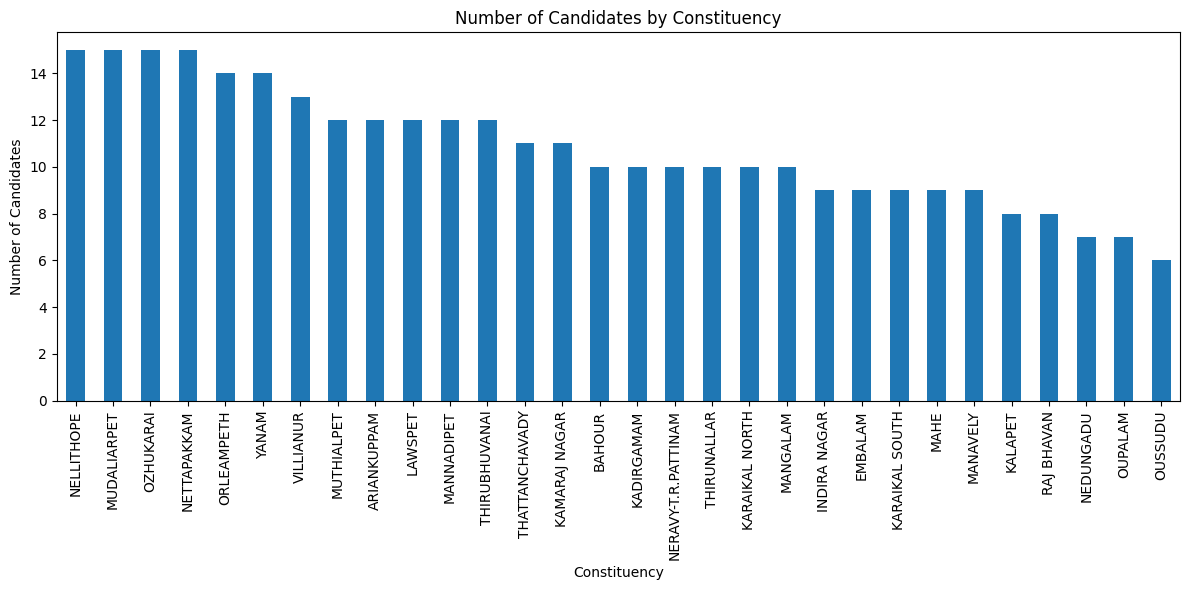

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

candidates_per_constituency.plot(kind="bar")

plt.title("Number of Candidates by Constituency")
plt.xlabel("Constituency")
plt.ylabel("Number of Candidates")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Key Insight

Candidate participation varies considerably across constituencies. **NELLITHOPE, MUDALIARPET, OZHUKARAI, and NETTAPAKKAM** have the highest number of candidate-result records, with **15 each**, while **OUSSUDU** has the lowest with **6**.

This variation provides an initial indication that electoral competition differs across constituencies and will be explored further using vote-based measures.

## Party Participation

Political party participation is an important aspect of election analysis. In this section, we will examine how many candidate-result records are associated with each political party.

This will help identify parties with relatively higher and lower levels of participation in the constituencies covered by the dataset.

### Analysis Question

Which political parties have the highest number of candidate-result records in the dataset?

In [11]:
party_candidate_count = (df.groupby("Party")["Candidate"].count().sort_values(ascending=False))

party_candidate_count

,Candidate
Party,
Independent,117
None of the Above,30
Naam Tamilar Katchi,28
Tamilaga Vettri Kazhagam,28
Indian National Congress,22
Pattali Makkal Katchi,19
All India N.R. Congress,16
Dravida Munnetra Kazhagam,13
Bharatiya Janata Party,10


### Interpretation

The party participation analysis shows considerable variation in the number of candidate-result records across the 26 party categories in the dataset.

**Independent** has the highest number of candidate-result records with **117**, followed by **None of the Above (NOTA)** with **30**. **Naam Tamilar Katchi** and **Tamilaga Vettri Kazhagam** each have **28** records, while the **Indian National Congress** has **22**.

At the lower end, several parties have only **one candidate-result record** in the dataset, including Communist Party of India, Anna Makkal Katchi, Loktantrik Janta Dal, Indian Union Muslim League, Parivartan Rajniti Party, and Socialist Unity Centre Of India (COMMUNIST).

The large difference between the highest and lowest participation levels indicates that candidate participation is highly uneven across party categories. However, the number of candidate records alone does not indicate electoral performance. Vote-based analysis will therefore be performed separately.

## Party Participation by Candidate-Result Records

The following bar chart visualizes the number of candidate-result records associated with each party category.

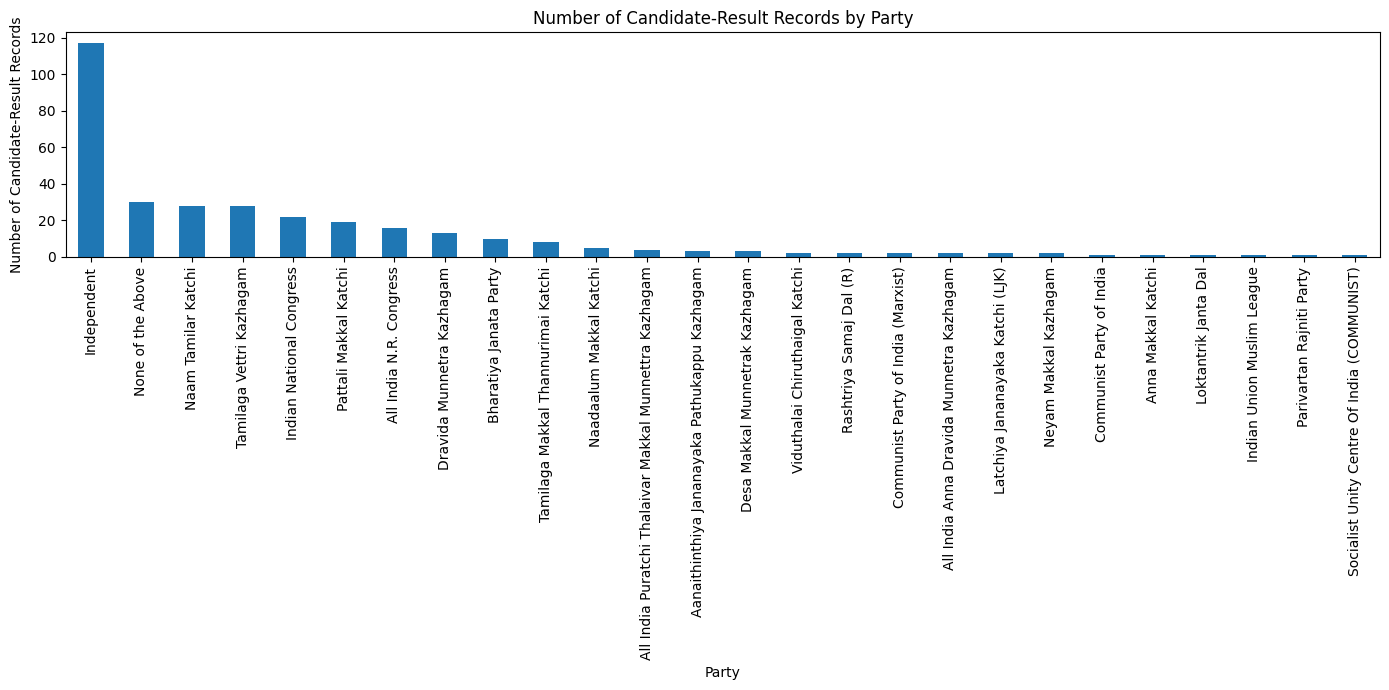

In [12]:
plt.figure(figsize=(14, 7))

party_candidate_count.plot(kind="bar")

plt.title("Number of Candidate-Result Records by Party")
plt.xlabel("Party")
plt.ylabel("Number of Candidate-Result Records")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Key Insight

The visualization highlights a substantial difference in candidate participation across party categories. The **Independent** category has a much larger number of candidate-result records than any individual political party, while several parties have only one or two records.

This shows that the election dataset contains a significant number of independent candidates in addition to candidates representing political parties. However, participation levels should not be interpreted as electoral success; subsequent analysis will compare parties based on their vote totals and vote percentages.

##  Party Performance by Total Votes

After examining party participation, we will analyze the total number of votes received by each party.

The total votes are calculated by summing the `Total Votes` received by all candidate-result records belonging to each party.

This analysis will help identify which party categories received the highest overall vote counts in the dataset.

In [13]:
party_total_votes = (df.groupby("Party")["Total Votes"].sum().sort_values(ascending=False))

party_total_votes

,Total Votes
Party,
All India N.R. Congress,200292
Indian National Congress,151934
Tamilaga Vettri Kazhagam,144817
Dravida Munnetra Kazhagam,119036
Bharatiya Janata Party,105583
Independent,75185
Latchiya Jananayaka Katchi (LJK),19903
Neyam Makkal Kazhagam,15543
Naam Tamilar Katchi,11813


### Analysis Question

Which party categories received the highest total number of votes across the constituencies?

### Interpretation

The party-wise total vote analysis shows substantial variation in the overall votes received by different party categories.

**All India N.R. Congress** recorded the highest total number of votes with **200,292**, followed by **Indian National Congress** with **151,934** and **Tamilaga Vettri Kazhagam** with **144,817**.

Other parties with relatively high total vote counts include **Dravida Munnetra Kazhagam** with **119,036** and **Bharatiya Janata Party** with **105,583**.

Interestingly, the **Independent** category had the highest number of candidate-result records in the previous analysis, with 117 records, but received **75,185 total votes**. This demonstrates that a higher number of participating candidates does not necessarily correspond to a higher overall vote total.

At the lower end, **Parivartan Rajniti Party** received 24 total votes, while **Anna Makkal Katchi** received 39 and **Rashtriya Samaj Dal (R)** received 47.

Overall, the analysis shows that total electoral support is distributed unevenly across party categories.

## Party-wise Total Votes

The following bar chart compares the total votes received by each party category across the constituencies.

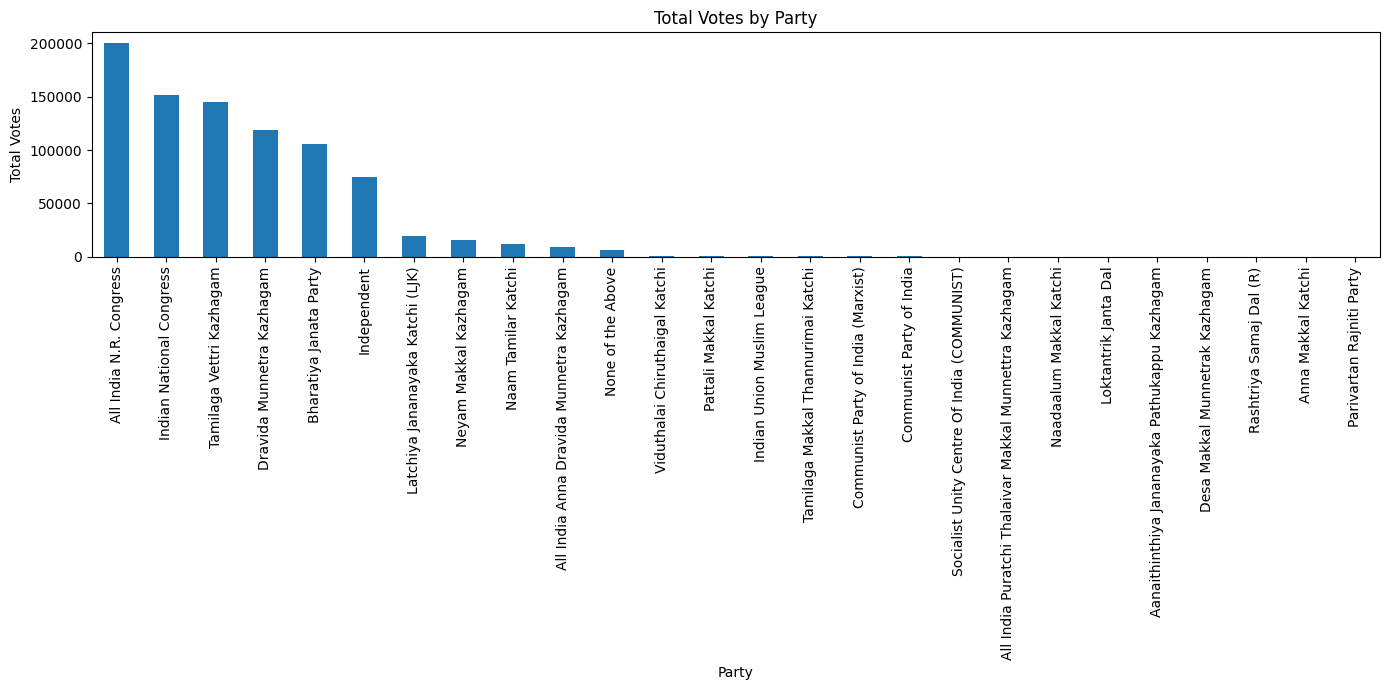

In [14]:
plt.figure(figsize=(14, 7))

party_total_votes.plot(kind="bar")

plt.title("Total Votes by Party")
plt.xlabel("Party")
plt.ylabel("Total Votes")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Key Insight

**All India N.R. Congress** received the highest overall number of votes in the dataset, with **200,292 votes**.

The comparison with the earlier party-participation analysis is particularly important: **Independent candidates had the largest number of candidate-result records (117), but their combined total was 75,185 votes**. Therefore, the number of candidates associated with a party category and its overall electoral support do not necessarily have a direct relationship.

##  Average Votes per Candidate-Result Record

To complement the total-vote analysis, we will calculate the average number of Total Votes received per candidate-result record for each party category.

This measure helps compare the typical vote performance of candidate-result records across different party categories, regardless of how many candidates are associated with each category.

The average is calculated as:

**Average Votes = Total Votes for the Party / Number of Candidate-Result Records for the Party**

In [15]:
party_avg_votes = (df.groupby("Party")["Total Votes"].mean().sort_values(ascending=False))

party_avg_votes

,Total Votes
Party,
All India N.R. Congress,12518.250000
Bharatiya Janata Party,10558.300000
Latchiya Jananayaka Katchi (LJK),9951.500000
Dravida Munnetra Kazhagam,9156.615385
Neyam Makkal Kazhagam,7771.500000
Indian National Congress,6906.090909
Tamilaga Vettri Kazhagam,5172.035714
All India Anna Dravida Munnetra Kazhagam,4699.500000
Indian Union Muslim League,800.000000


### Interpretation

The average vote analysis shows substantial differences in the typical vote performance of candidate-result records across party categories.

**All India N.R. Congress** recorded the highest average with approximately **12,518.25 votes per candidate-result record**, followed by the **Bharatiya Janata Party** with **10,558.30** and **Latchiya Jananayaka Katchi (LJK)** with **9,951.50**.

**Dravida Munnetra Kazhagam** and **Indian National Congress** also recorded relatively high average vote counts of approximately **9,156.62** and **6,906.09**, respectively.

An important observation is the difference between participation and average performance. The **Independent** category had the highest number of candidate-result records at 117, but its average was approximately **642.61 votes per record**. This demonstrates that a larger number of participating candidates does not necessarily result in higher average vote performance.

Party categories with only one candidate-result record should be interpreted carefully because their average is based on a single observation.

## Average Votes per Candidate-Result Record by Party

The following visualization compares the average Total Votes received per candidate-result record across party categories.

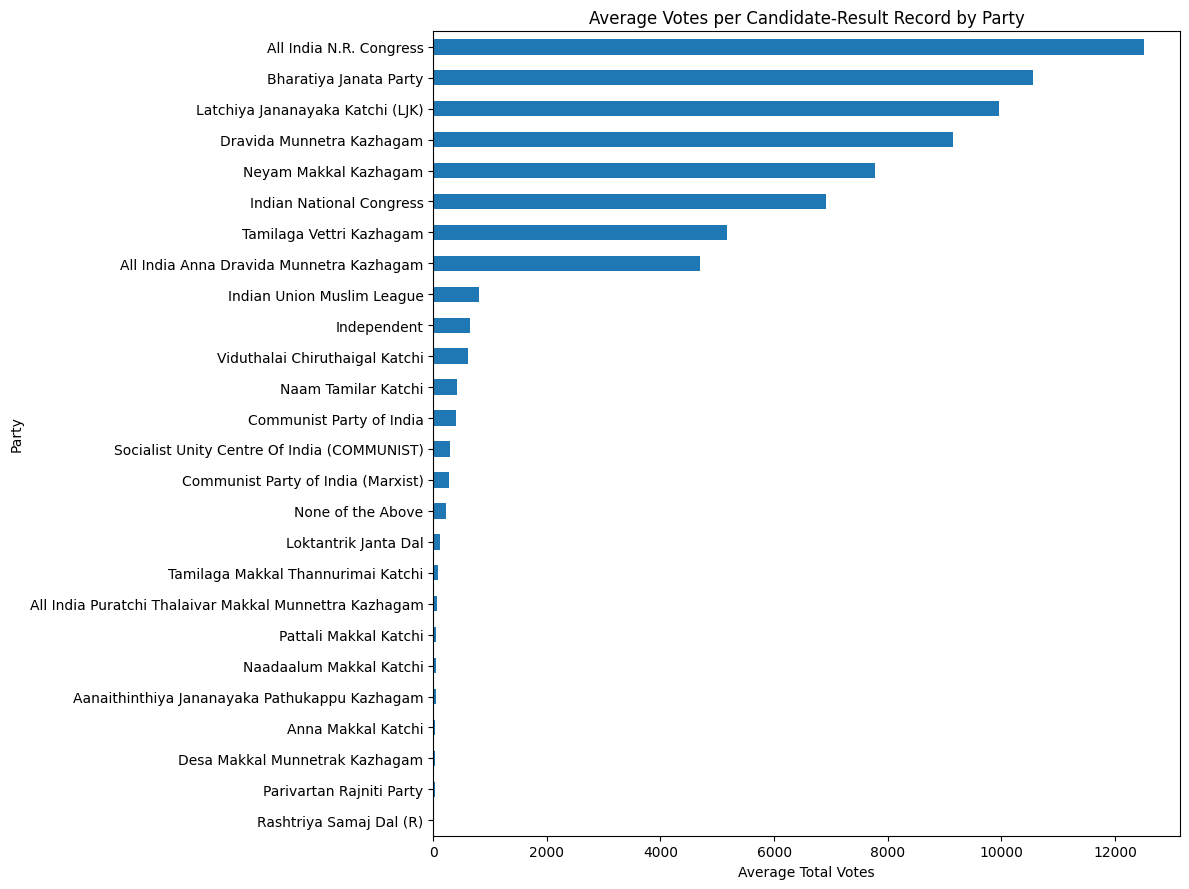

In [16]:
plt.figure(figsize=(12, 9))

party_avg_votes.sort_values().plot(kind="barh")

plt.title("Average Votes per Candidate-Result Record by Party")
plt.xlabel("Average Total Votes")
plt.ylabel("Party")

plt.tight_layout()
plt.show()

### Key Insight

The average-vote analysis provides a different perspective from total-vote analysis. **All India N.R. Congress** has the highest average vote count per candidate-result record, while the **Independent** category, despite having the largest number of candidate-result records, has a considerably lower average.

This demonstrates why both total votes and average votes are useful measures: total votes reflect overall accumulated support, whereas average votes provide an indication of typical candidate-result performance within each party category.

##  Vote Distribution Analysis

The distribution of Total Votes across candidate-result records will be analyzed to understand how electoral support is distributed among candidates.

This analysis will help identify the typical vote count, the spread of vote totals, and whether a small number of candidate-result records received exceptionally high numbers of votes.

In [17]:
df["Total Votes"].describe()

,Total Votes
count,324.000000
mean,2673.268519
std,4507.650787
min,4.000000
25%,50.500000
50%,195.500000
75%,3573.500000
max,19863.000000


### Analysis Question

What is the distribution of Total Votes among the 324 candidate-result records?

### Interpretation

The dataset contains **324 candidate-result records**. The average number of Total Votes is approximately **2,673.27**, while the median is only **195.50 votes**.

The large difference between the mean and median indicates that the vote distribution is **highly right-skewed**. A relatively small number of candidate-result records received very large numbers of votes, which increases the overall mean.

The minimum Total Votes is **4**, while the maximum is **19,863**, showing a substantial range in electoral support.

The standard deviation is approximately **4,507.65**, which is considerably larger than the mean. This further indicates a high degree of variation in vote totals across candidate-result records.

The 25th percentile is **50.5 votes**, meaning approximately 25% of the records received 50.5 votes or fewer. The 75th percentile is **3,573.5 votes**, showing that the upper portion of the distribution contains substantially higher vote totals.

Overall, the descriptive statistics indicate that candidate vote totals are highly uneven and strongly influenced by a smaller number of high-vote candidates.

## Distribution of Total Votes

A histogram is used to visualize the distribution of Total Votes across candidate-result records and to examine the concentration and spread of vote totals.

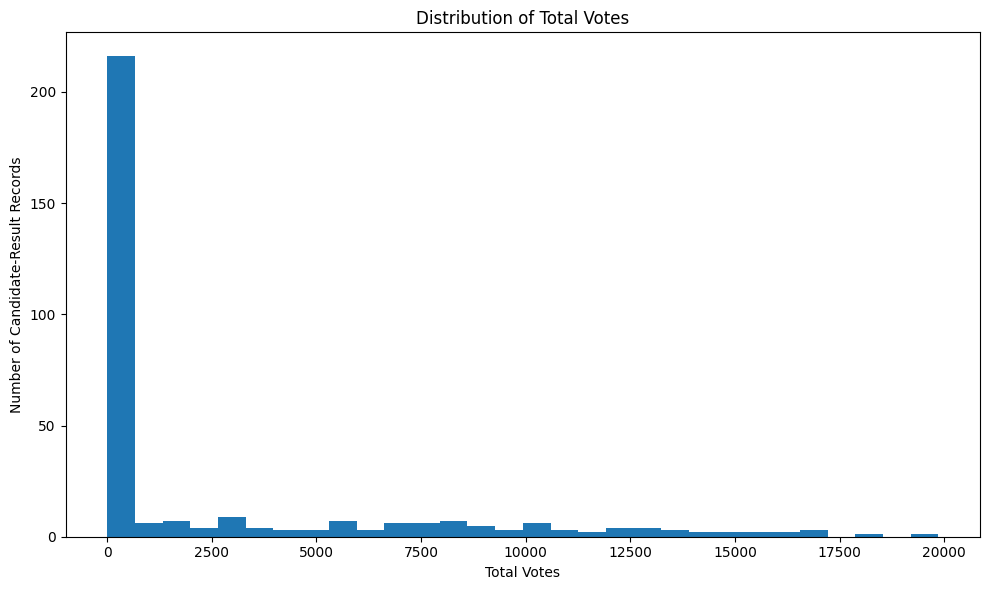

In [18]:
plt.figure(figsize=(10, 6))

plt.hist(df["Total Votes"], bins=30)

plt.title("Distribution of Total Votes")
plt.xlabel("Total Votes")
plt.ylabel("Number of Candidate-Result Records")

plt.tight_layout()
plt.show()

### Key Insight

The histogram shows that most candidate-result records are concentrated toward the lower end of the vote distribution, while a smaller number of records have substantially higher vote totals.

This confirms the strong right-skew observed in the descriptive statistics. Therefore, the **median of 195.5 votes** provides a more representative measure of a typical candidate-result record than the mean of **2,673.27 votes**.

##Top 10 Candidate-Result Records by Total Votes

The top candidate-result records will be identified based on Total Votes.

This analysis will help determine which candidates received the highest levels of electoral support in the dataset.

In [19]:
top_10_candidates = (df[["Candidate", "Party", "Constituency", "Total Votes", "% of Votes"]].sort_values("Total Votes", ascending=False).head(10))

top_10_candidates

,Candidate,Party,Constituency,Total Votes,% of Votes
129,MALLADI KRISHNA RAO,All India N.R. Congress,YANAM,19863,55.44
1,N. RANGASAMY,All India N.R. Congress,MANGALAM,17917,50.61
11,B.RAVICOUMAR,All India N.R. Congress,VILLIANUR,16970,43.13
220,G.N.S. RAJASEKARAN,Bharatiya Janata Party,THIRUNALLAR,16829,60.18
297,JOSE CHARLES MARTIN,Latchiya Jananayaka Katchi (LJK),KAMARAJ NAGAR,16592,53.14
95,E. MOHANDOSS,All India N.R. Congress,EMBALAM,16017,50.78
193,A. NAMASSIVAYAM,Bharatiya Janata Party,MANNADIPET,15918,53.96
286,P. KARTHIKEYAN,Indian National Congress,OUSSUDU,15400,49.20
128,GOLLAPALLI SRINIVAS ASHOK,Indian National Congress,YANAM,15295,42.69
10,R.SIVA,Dravida Munnetra Kazhagam,VILLIANUR,15000,38.12


### Interpretation

The top 10 candidate-result records by Total Votes show substantial electoral support for several candidates across different constituencies.

**MALLADI KRISHNA RAO** of **All India N.R. Congress** recorded the highest Total Votes in the dataset, with **19,863 votes** in **YANAM**, representing **55.44%** of the votes.

The second-highest result was recorded by **N. RANGASAMY** of **All India N.R. Congress** in **MANGALAM**, with **17,917 votes** and **50.61%** of the votes.

**B.RAVICOUMAR** of All India N.R. Congress ranked third with **16,970 votes** in **VILLIANUR**.

Among the top 10 records, candidates from **All India N.R. Congress, Bharatiya Janata Party, Latchiya Jananayaka Katchi (LJK), Indian National Congress, and Dravida Munnetra Kazhagam** are represented.

The highest Total Votes recorded in the dataset is **19,863**, while all of the top 10 candidate-result records received at least **15,000 votes**.

## Top 10 Candidate-Result Records by Total Votes

The following visualization compares the ten candidate-result records with the highest Total Votes.

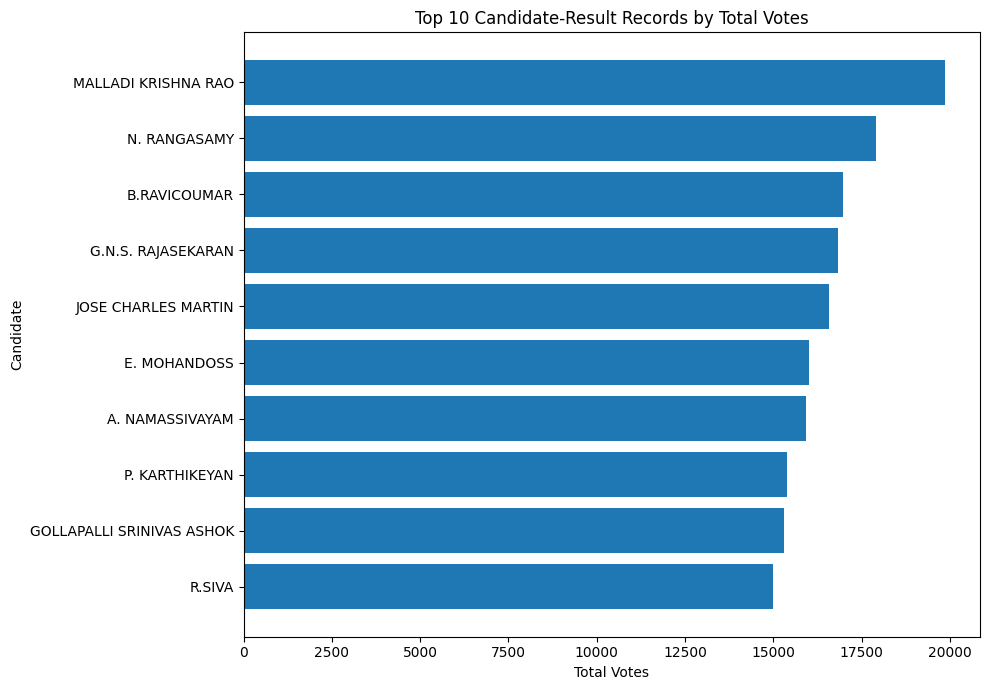

In [20]:
top_10_candidates_sorted = top_10_candidates.sort_values("Total Votes",ascending=True)

plt.figure(figsize=(10, 7))

plt.barh(top_10_candidates_sorted["Candidate"],top_10_candidates_sorted["Total Votes"])

plt.title("Top 10 Candidate-Result Records by Total Votes")
plt.xlabel("Total Votes")
plt.ylabel("Candidate")

plt.tight_layout()
plt.show()

### Key Insight

The top 10 candidate-result records received between **15,000 and 19,863 votes**. **MALLADI KRISHNA RAO** recorded the highest vote total with **19,863 votes**, followed by **N. RANGASAMY** with **17,917 votes**.

The results also show that **All India N.R. Congress** appears multiple times among the highest-vote candidate-result records, indicating strong representation among the highest individual vote totals in this dataset.

## Candidate Performance by Vote Percentage

Total Votes measure the absolute number of votes received, while `% of Votes` measures the proportion of votes received within the constituency.

Analyzing vote percentage allows us to identify candidate-result records with the strongest relative electoral support.

### Analysis Question

Which candidate-result records achieved the highest percentage of votes in their respective constituencies?

In [21]:
top_10_vote_percentage = (df[["Candidate", "Party", "Constituency", "Total Votes", "% of Votes"]].sort_values("% of Votes", ascending=False).head(10))

top_10_vote_percentage

,Candidate,Party,Constituency,Total Votes,% of Votes
220,G.N.S. RAJASEKARAN,Bharatiya Janata Party,THIRUNALLAR,16829,60.18
129,MALLADI KRISHNA RAO,All India N.R. Congress,YANAM,19863,55.44
193,A. NAMASSIVAYAM,Bharatiya Janata Party,MANNADIPET,15918,53.96
297,JOSE CHARLES MARTIN,Latchiya Jananayaka Katchi (LJK),KAMARAJ NAGAR,16592,53.14
266,AZHAGU @ AZHAGANANTHAM,Independent,KADIRGAMAM,14633,51.35
316,G. NEHRU ALIAS COUPPOUSSAMY,Neyam Makkal Kazhagam,ORLEAMPETH,9960,50.83
95,E. MOHANDOSS,All India N.R. Congress,EMBALAM,16017,50.78
1,N. RANGASAMY,All India N.R. Congress,MANGALAM,17917,50.61
275,DR. V. VIGNESWARAN,Independent,NEDUNGADU,14368,50.54
286,P. KARTHIKEYAN,Indian National Congress,OUSSUDU,15400,49.20


### Interpretation

The vote-percentage analysis identifies the candidate-result records with the highest relative electoral support within their respective constituencies.

**G.N.S. RAJASEKARAN** of the **Bharatiya Janata Party** recorded the highest vote percentage in the dataset, receiving **60.18%** of the votes in **THIRUNALLAR**, with a total of **16,829 votes**.

**MALLADI KRISHNA RAO** of **All India N.R. Congress** ranked second with **55.44%** in **YANAM**, while **A. NAMASSIVAYAM** of the **Bharatiya Janata Party** ranked third with **53.96%** in **MANNADIPET**.

Among the top 10 candidate-result records, the vote percentages range from **60.18% to 49.20%**. Both major political parties and other party categories, including Independent candidates, are represented among the highest vote-percentage records.

The analysis demonstrates that vote percentage provides a useful measure of relative electoral support, complementing the earlier analysis based on absolute Total Votes.

## Top 10 Candidate-Result Records by Vote Percentage

The following visualization compares the candidate-result records with the highest vote percentages in the dataset.

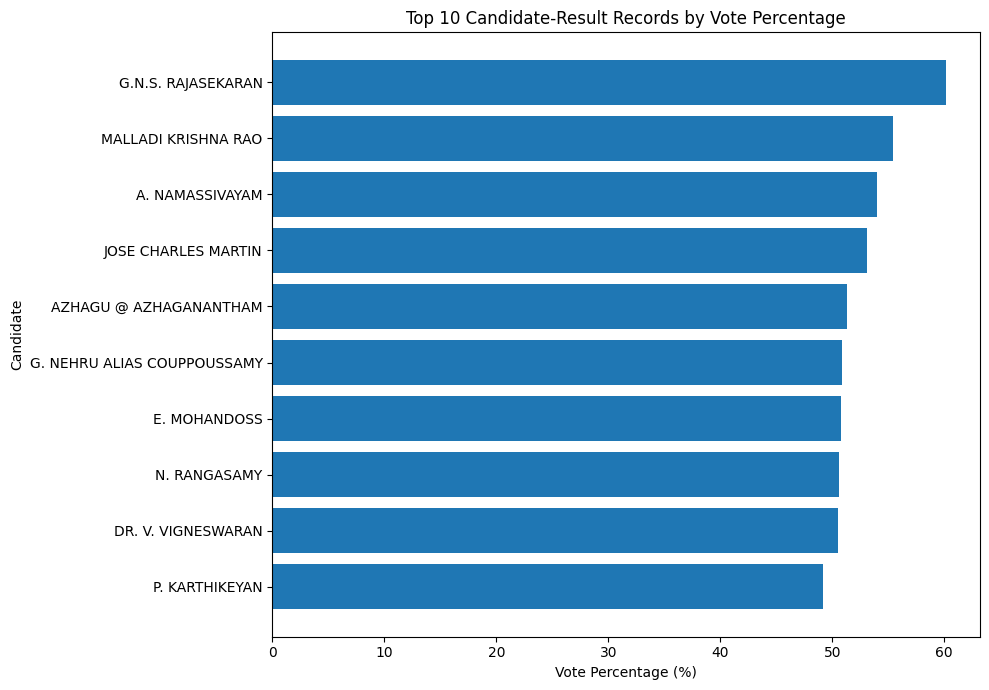

In [22]:
top_10_vote_percentage_sorted = top_10_vote_percentage.sort_values("% of Votes",ascending=True)

plt.figure(figsize=(10, 7))

plt.barh(top_10_vote_percentage_sorted["Candidate"],top_10_vote_percentage_sorted["% of Votes"])

plt.title("Top 10 Candidate-Result Records by Vote Percentage")
plt.xlabel("Vote Percentage (%)")
plt.ylabel("Candidate")

plt.tight_layout()
plt.show()

### Key Insight

**G.N.S. RAJASEKARAN** recorded the highest vote percentage in the dataset at **60.18%** in **THIRUNALLAR**. This indicates that the candidate secured more than half of the votes represented in the constituency-level result.

The analysis also shows that several of the highest vote-percentage results were above 50%, indicating strong relative electoral support in their respective constituencies.

## Constituency-Level Winner Analysis

For each constituency, the candidate with the highest `Total Votes` will be identified as the leading candidate in that constituency.

This analysis provides a constituency-level view of electoral outcomes and helps identify which candidates and party categories secured the highest vote totals across the 30 constituencies.

### Analysis Question

Who received the highest number of Total Votes in each constituency, and which party did the leading candidate represent?

In [23]:
constituency_winners = (df.loc[df.groupby("Constituency")["Total Votes"].idxmax()][
                        ["Constituency", "Candidate", "Party", "Total Votes", "% of Votes"]]
                        .sort_values("Constituency"))

constituency_winners

,Constituency,Candidate,Party,Total Votes,% of Votes
82,ARIANKUPPAM,C. AIYAPPAN @ MOUTTAYAPPAN,All India N.R. Congress,14210,41.18
173,BAHOUR,R. SENTHIL KUMAR,Dravida Munnetra Kazhagam,10520,38.32
95,EMBALAM,E. MOHANDOSS,All India N.R. Congress,16017,50.78
38,INDIRA NAGAR,P.V. AROUMOUGAME @ AKD,All India N.R. Congress,12640,42.13
266,KADIRGAMAM,AZHAGU @ AZHAGANANTHAM,Independent,14633,51.35
143,KALAPET,SENTHIL @ RAMESH,Dravida Munnetra Kazhagam,12069,38.26
297,KAMARAJ NAGAR,JOSE CHARLES MARTIN,Latchiya Jananayaka Katchi (LJK),16592,53.14
118,KARAIKAL NORTH,P.R.N. THIRUMURUGAN,All India N.R. Congress,12731,43.59
185,KARAIKAL SOUTH,A.M.H. NAZEEM,Dravida Munnetra Kazhagam,12543,49.15
58,LAWSPET,V.P. SIVAKOLUNDHU,All India N.R. Congress,10578,39.52


### Interpretation

The constituency-level analysis identifies the candidate with the highest `Total Votes` in each of the 30 constituencies.

**MALLADI KRISHNA RAO** of **All India N.R. Congress** recorded the highest winning vote total, with **19,863 votes** in **YANAM**. Other high vote totals among constituency leaders include **N. RANGASAMY** in MANGALAM with **17,917 votes**, **B.RAVICOUMAR** in VILLIANUR with **16,970 votes**, and **G.N.S. RAJASEKARAN** in THIRUNALLAR with **16,829 votes**.

The lowest winning vote total among the 30 constituency leaders was recorded by **VIGNESH KANNAN** in **RAJ BHAVAN**, with **7,304 votes**.

The highest winning vote percentage was recorded by **G.N.S. RAJASEKARAN** in **THIRUNALLAR**, with **60.18%**, while the lowest winning vote percentage was recorded by **AK. SAI J SARAVANAN KUMAR** in **THIRUBHUVANAI**, with **32.15%**.

The results show that the leading candidate varies considerably across constituencies, both in terms of absolute votes and percentage of votes.

##  Party-wise Constituency Wins

After identifying the leading candidate in each constituency, we will count the number of constituencies in which each party category had the highest Total Votes.

This provides a constituency-level comparison of party performance across the 30 constituencies.

### Analysis Question

Which party categories had the highest number of constituency-level leaders?

In [24]:
party_wins = (constituency_winners["Party"].value_counts().sort_values(ascending=False))

party_wins

,count
Party,
All India N.R. Congress,12
Dravida Munnetra Kazhagam,5
Bharatiya Janata Party,4
Independent,3
Tamilaga Vettri Kazhagam,2
Latchiya Jananayaka Katchi (LJK),1
Neyam Makkal Kazhagam,1
All India Anna Dravida Munnetra Kazhagam,1
Indian National Congress,1


### Interpretation

The party-wise constituency analysis shows that **All India N.R. Congress** has the highest number of constituency-level leaders, with **12 out of 30 constituencies**.

**Dravida Munnetra Kazhagam** follows with **5 constituencies**, while the **Bharatiya Janata Party** has **4 constituency-level leaders**. Independent candidates lead in **3 constituencies**, followed by **Tamilaga Vettri Kazhagam** with **2 constituencies**.

**Latchiya Jananayaka Katchi (LJK)**, **Neyam Makkal Kazhagam**, **All India Anna Dravida Munnetra Kazhagam**, and **Indian National Congress** each have **1 constituency-level leader**.

Overall, the results show that constituency-level leadership is concentrated among a smaller number of party categories, with All India N.R. Congress having the largest representation among the highest-vote candidates.

## Party-wise Constituency Leaders

The following bar chart shows the number of constituencies in which each party category had the highest Total Votes.

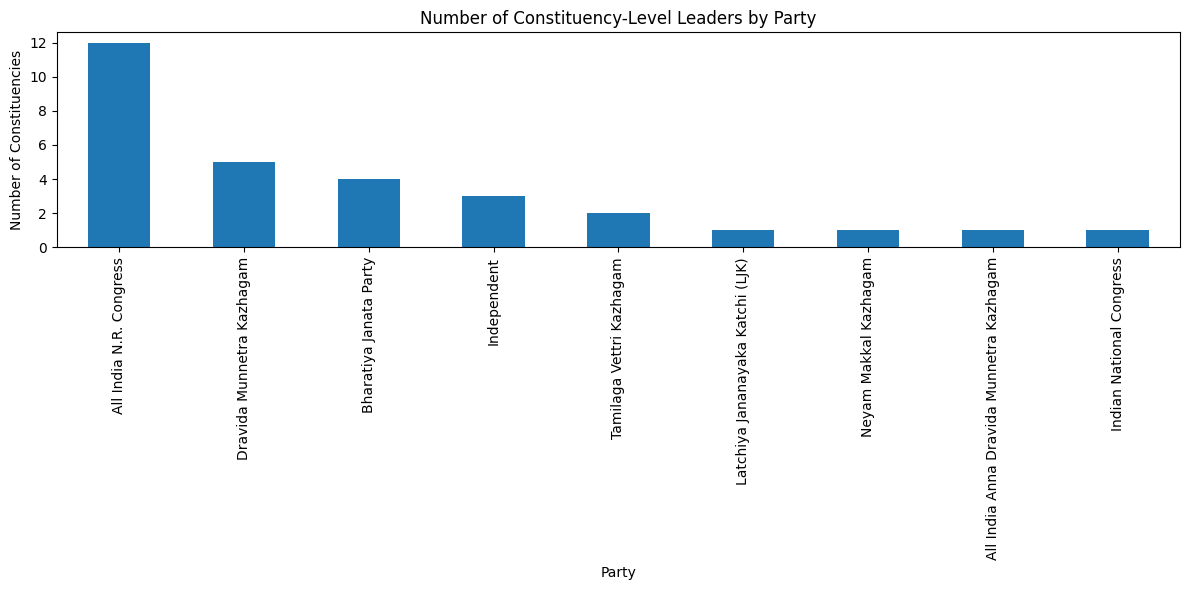

In [26]:
plt.figure(figsize=(12, 6))

party_wins.plot(kind="bar")

plt.title("Number of Constituency-Level Leaders by Party")
plt.xlabel("Party")
plt.ylabel("Number of Constituencies")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Key Insight

All India N.R. Congress has the highest representation among constituency-level leaders, leading in **12 of the 30 constituencies**.

Dravida Munnetra Kazhagam and Bharatiya Janata Party follow with **5 and 4 constituencies**, respectively.

Together, these three party categories account for **21 of the 30 constituency-level leaders**, indicating that the highest-vote positions are concentrated among these party categories in the dataset.

## Constituency-wise Winning Margin

The winning margin is calculated as the difference between the highest and second-highest `Total Votes` within each constituency.

A smaller margin indicates a relatively closer contest, while a larger margin indicates a greater difference in vote totals between the leading candidate and the runner-up.

This analysis helps identify constituencies with the closest and most decisive contests.

### Analysis Question

Which constituencies had the closest contests, and which had the largest winning margins?

In [62]:
# Sort candidates by constituency and Total Votes
df_sorted = df.sort_values(["Constituency", "Total Votes"],ascending=[True, False])

# Get the top two candidates from each constituency
top_two = df_sorted.groupby("Constituency").head(2)

# Calculate winning margin
winning_margins = (top_two.groupby("Constituency")["Total Votes"]
    .apply(lambda x: x.iloc[0] - x.iloc[1])
    .sort_values(ascending=False))

winning_margins

,Total Votes
Constituency,
KAMARAJ NAGAR,10205
THIRUNALLAR,9526
MANGALAM,7050
KADIRGAMAM,7004
NETTAPAKKAM,6689
MANNADIPET,6110
KARAIKAL SOUTH,5862
YANAM,4568
NEDUNGADU,4499


### Interpretation

The constituency-wise winning margin analysis shows considerable variation in the difference between the highest and second-highest Total Votes.

**KAMARAJ NAGAR** recorded the largest winning margin of **10,205 votes**, followed by **THIRUNALLAR** with a margin of **9,526 votes** and **MANGALAM** with **7,050 votes**. These large margins indicate a substantial difference between the leading candidate and the runner-up.

At the other end, **RAJ BHAVAN** recorded the closest contest, with a winning margin of only **287 votes**. This was followed by **KALAPET** with **447 votes** and **INDIRA NAGAR** with **584 votes**.

Overall, the winning margins range from **287 to 10,205 votes**, demonstrating that the level of competition varied substantially across constituencies.

## Detailed Winning-Margin Table

A detailed winning-margin table is created to compare the leading candidate with the runner-up in each constituency.

The table includes the constituency, leading candidate, leading candidate's party, leading candidate's votes, runner-up, runner-up's party, runner-up's votes, and the winning margin.

The winning margin is calculated as:

**Winning Margin = Winner's Total Votes − Runner-up's Total Votes**

In [7]:
winning_margin_details = []

for constituency, group in df.groupby("Constituency"):
    group = group.sort_values("Total Votes", ascending=False)

    winner = group.iloc[0]
    runner_up = group.iloc[1]

    winning_margin_details.append({
        "Constituency": constituency,
        "Winner": winner["Candidate"],
        "Winner Party": winner["Party"],
        "Winner Votes": winner["Total Votes"],
        "Runner-up": runner_up["Candidate"],
        "Runner-up Party": runner_up["Party"],
        "Runner-up Votes": runner_up["Total Votes"],
        "Winning Margin": winner["Total Votes"] - runner_up["Total Votes"]
    })

winning_margin_df = pd.DataFrame(winning_margin_details)

winning_margin_df = winning_margin_df.sort_values("Winning Margin",ascending=False)

winning_margin_df

,Constituency,Winner,Winner Party,Winner Votes,Runner-up,Runner-up Party,Runner-up Votes,Winning Margin
6,KAMARAJ NAGAR,JOSE CHARLES MARTIN,Latchiya Jananayaka Katchi (LJK),16592,P.K. DEVADOSS,Indian National Congress,6387,10205
27,THIRUNALLAR,G.N.S. RAJASEKARAN,Bharatiya Janata Party,16829,R. KAMALAKANNAN,Indian National Congress,7303,9526
12,MANGALAM,N. RANGASAMY,All India N.R. Congress,17917,S.S. RANGAN,Dravida Munnetra Kazhagam,10867,7050
4,KADIRGAMAM,AZHAGU @ AZHAGANANTHAM,Independent,14633,K.S.P @ S. RAMESH,All India N.R. Congress,7629,7004
19,NETTAPAKKAM,P. RAJAVELU,All India N.R. Congress,13665,G. ANBARASAN,Indian National Congress,6976,6689
13,MANNADIPET,A. NAMASSIVAYAM,Bharatiya Janata Party,15918,T.P.R. SELVAME,Indian National Congress,9808,6110
8,KARAIKAL SOUTH,A.M.H. NAZEEM,Dravida Munnetra Kazhagam,12543,AVS SAKTHIVEL PRABU,Indian National Congress,6681,5862
29,YANAM,MALLADI KRISHNA RAO,All India N.R. Congress,19863,GOLLAPALLI SRINIVAS ASHOK,Indian National Congress,15295,4568
16,NEDUNGADU,DR. V. VIGNESWARAN,Independent,14368,C. CHANDIRA PRIYANGA,All India N.R. Congress,9869,4499
25,THATTANCHAVADY,N. RANGASAMY,All India N.R. Congress,10024,E. VINAYAGAM,Neyam Makkal Kazhagam,5583,4441


### Interpretation

The detailed winning-margin table provides a constituency-level comparison between the leading candidate and the runner-up.

For each constituency, the winning margin represents the difference between the highest and second-highest Total Votes. A larger margin indicates a more decisive lead, while a smaller margin indicates a closer contest.

The table contains results for all **30 constituencies**, allowing the winning margins and the corresponding leading and runner-up candidates to be compared systematically.

## Largest and Closest Constituency Contests

The largest and smallest winning margins are examined to identify the most decisive and closest constituency-level contests.

A large winning margin indicates a substantial difference between the leading candidate and the runner-up, while a small winning margin indicates a closely contested result.

In [30]:
print("Top 5 Largest Winning Margins:")
display(winning_margin_df.sort_values("Winning Margin", ascending=False).head(5))

print("\nTop 5 Closest Contests:")
display(winning_margin_df.sort_values("Winning Margin", ascending=True).head(5))

Top 5 Largest Winning Margins:


,Constituency,Winner,Winner Party,Winner Votes,Runner-up,Runner-up Party,Runner-up Votes,Winning Margin
6,KAMARAJ NAGAR,JOSE CHARLES MARTIN,Latchiya Jananayaka Katchi (LJK),16592,P.K. DEVADOSS,Indian National Congress,6387,10205
27,THIRUNALLAR,G.N.S. RAJASEKARAN,Bharatiya Janata Party,16829,R. KAMALAKANNAN,Indian National Congress,7303,9526
12,MANGALAM,N. RANGASAMY,All India N.R. Congress,17917,S.S. RANGAN,Dravida Munnetra Kazhagam,10867,7050
4,KADIRGAMAM,AZHAGU @ AZHAGANANTHAM,Independent,14633,K.S.P @ S. RAMESH,All India N.R. Congress,7629,7004
19,NETTAPAKKAM,P. RAJAVELU,All India N.R. Congress,13665,G. ANBARASAN,Indian National Congress,6976,6689



Top 5 Closest Contests:


,Constituency,Winner,Winner Party,Winner Votes,Runner-up,Runner-up Party,Runner-up Votes,Winning Margin
24,RAJ BHAVAN,VIGNESH KANNAN,Dravida Munnetra Kazhagam,7304,V. P. RAMALINGAME,Bharatiya Janata Party,7017,287
5,KALAPET,SENTHIL @ RAMESH,Dravida Munnetra Kazhagam,12069,P.M.L. KALYANASUNDARAM,Bharatiya Janata Party,11622,447
3,INDIRA NAGAR,P.V. AROUMOUGAME @ AKD,All India N.R. Congress,12640,S. MOUROUGANE,Tamilaga Vettri Kazhagam,12056,584
0,ARIANKUPPAM,C. AIYAPPAN @ MOUTTAYAPPAN,All India N.R. Congress,14210,VIZAYALAKSHMY DJEAMOURTHY,Indian National Congress,13607,603
26,THIRUBHUVANAI,AK. SAI J SARAVANAN KUMAR,Tamilaga Vettri Kazhagam,9740,B. KOBIGA,All India N.R. Congress,9039,701


### Analysis Question

Which constituencies had the most decisive contests, and which constituencies had the closest contests based on the winning margin?

### Interpretation

The winning-margin analysis reveals substantial variation in the competitiveness of the 30 constituencies.

Among the largest winning margins, **KAMARAJ NAGAR** recorded the most decisive contest. **JOSE CHARLES MARTIN** of **Latchiya Jananayaka Katchi (LJK)** received **16,592 votes**, compared with **6,387 votes** for **P.K. DEVADOSS** of the Indian National Congress, resulting in a winning margin of **10,205 votes**.

The second-largest margin was recorded in **THIRUNALLAR**, where **G.N.S. RAJASEKARAN** of the Bharatiya Janata Party led by **9,526 votes**. **MANGALAM** recorded the third-largest margin of **7,050 votes**, with **N. RANGASAMY** leading the constituency.

In contrast, **RAJ BHAVAN** was the closest contest in the dataset. **VIGNESH KANNAN** of Dravida Munnetra Kazhagam received **7,304 votes**, only **287 votes** more than **V. P. RAMALINGAME** of the Bharatiya Janata Party.

The next closest contests were **KALAPET**, with a margin of **447 votes**, and **INDIRA NAGAR**, with a margin of **584 votes**.

Overall, the winning margins range from only **287 votes** to **10,205 votes**, demonstrating considerable variation in the competitiveness of constituency-level contests.

##Winning Margin by Constituency

The following visualization compares the winning margins across all 30 constituencies. Constituencies with smaller margins represent closer contests, while larger margins represent more decisive leads.

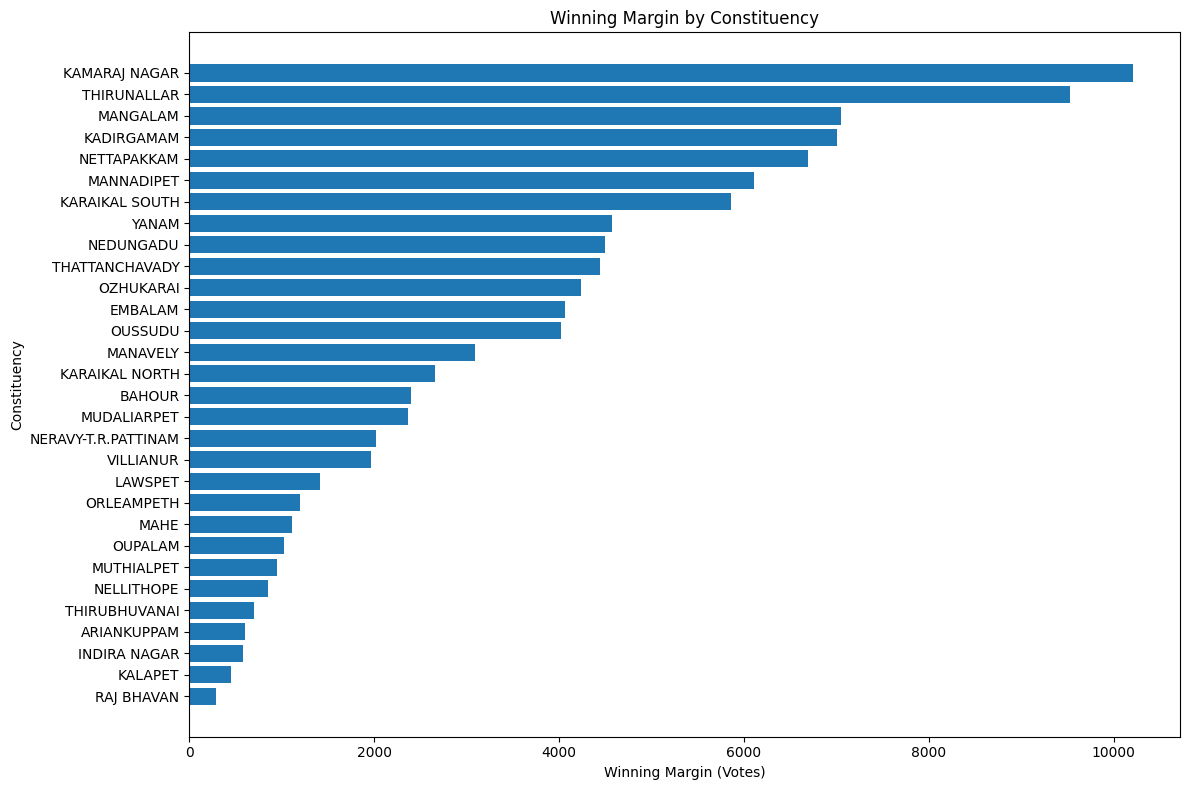

In [64]:
winning_margin_chart = winning_margin_df.sort_values("Winning Margin",ascending=True)

plt.figure(figsize=(12, 8))

plt.barh(winning_margin_chart["Constituency"],winning_margin_chart["Winning Margin"])

plt.title("Winning Margin by Constituency")
plt.xlabel("Winning Margin (Votes)")
plt.ylabel("Constituency")

plt.tight_layout()
plt.show()

### Key Insight

The winning-margin visualization demonstrates that electoral competitiveness varies considerably across constituencies.

**RAJ BHAVAN, KALAPET, and INDIRA NAGAR** had relatively close contests, with winning margins of **287, 447, and 584 votes**, respectively.

In contrast, **KAMARAJ NAGAR, THIRUNALLAR, and MANGALAM** recorded substantially larger margins of **10,205, 9,526, and 7,050 votes**, respectively.

Therefore, the dataset contains both closely contested constituencies and constituencies where the leading candidate had a substantial vote advantage.

## EVM Votes vs Postal Votes

The dataset contains separate EVM Vote and Postal Vote counts for each candidate-result record.

This analysis compares EVM Votes and Postal Votes to understand their relative contribution to the Total Votes received across the dataset.

### Analysis Question

How do EVM Votes and Postal Votes contribute to the overall Total Votes in the dataset?

In [65]:
evm_total = df["EVM Votes"].sum()
postal_total = df["Postal Votes"].sum()
total_votes = df["Total Votes"].sum()

print("Total EVM Votes:", evm_total)
print("Total Postal Votes:", postal_total)
print("Total Votes:", total_votes)

Total EVM Votes: 853899
Total Postal Votes: 12240
Total Votes: 866139


### Interpretation

The analysis shows that the dataset contains **866,139 Total Votes**, of which **853,899 votes** were recorded through Electronic Voting Machines (EVMs), while **12,240 votes** were recorded as Postal Votes.

EVM Votes therefore account for the vast majority of the Total Votes, while Postal Votes represent a relatively small proportion of the overall votes.

The results confirm that the `Total Votes` column is consistent with the sum of `EVM Votes` and `Postal Votes`, as:

**853,899 + 12,240 = 866,139**

This demonstrates that both voting methods are properly represented in the dataset and that the vote totals are internally consistent.

##  EVM vs Postal Vote Distribution

The distribution of EVM Votes and Postal Votes is visualized to compare their contribution to the overall Total Votes in the dataset.

This visualization helps illustrate the relative share of votes recorded through EVMs and postal ballots.

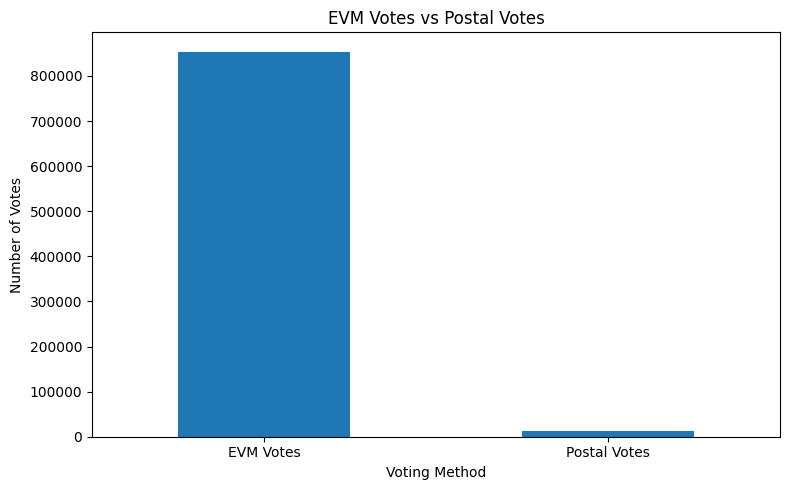

In [66]:
vote_method_totals = pd.Series({"EVM Votes": evm_total,"Postal Votes": postal_total})

plt.figure(figsize=(8, 5))

vote_method_totals.plot(kind="bar")

plt.title("EVM Votes vs Postal Votes")
plt.xlabel("Voting Method")
plt.ylabel("Number of Votes")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation

The visualization shows a substantial difference between EVM Votes and Postal Votes.

EVM Votes account for approximately **98.59%** of the Total Votes, while Postal Votes account for approximately **1.41%**.

This indicates that the overwhelming majority of votes in the dataset were recorded through EVMs, while postal ballots represented a relatively small share of the overall vote count.

The combined EVM and Postal Vote totals equal the Total Votes, confirming the internal consistency of the voting-method data.

##  Constituency-wise Vote Analysis

This analysis examines the total number of votes recorded in each constituency by aggregating the `Total Votes` column.

The purpose is to compare the overall voting volume across constituencies and identify constituencies with the highest and lowest total vote counts.

### Analysis Question

Which constituencies recorded the highest and lowest total number of votes?

In [54]:
constituency_votes = (df.groupby("Constituency")["Total Votes"].sum().sort_values(ascending=False))

constituency_votes

,Total Votes
Constituency,
VILLIANUR,39346
OZHUKARAI,35893
YANAM,35826
MANGALAM,35405
ARIANKUPPAM,34510
MANAVELY,32386
KALAPET,31545
EMBALAM,31542
OUSSUDU,31301


In [8]:
print("Highest Total Votes:")
print(constituency_votes.head(5))

print("\nLowest Total Votes:")
print(constituency_votes.tail(5))

Highest Total Votes:
Constituency
VILLIANUR      39346
OZHUKARAI      35893
YANAM          35826
MANGALAM       35405
ARIANKUPPAM    34510
Name: Total Votes, dtype: int64

Lowest Total Votes:
Constituency
THATTANCHAVADY    23578
MUTHIALPET        23560
OUPALAM           23030
ORLEAMPETH        19594
RAJ BHAVAN        18716
Name: Total Votes, dtype: int64


### Interpretation

The constituency-wise vote analysis shows considerable variation in the total number of votes recorded across the 30 constituencies.

**VILLIANUR** recorded the highest total vote count with **39,346 votes**, followed by **OZHUKARAI** with **35,893 votes** and **YANAM** with **35,826 votes**. **MANGALAM** and **ARIANKUPPAM** also recorded relatively high total vote counts of **35,405** and **34,510**, respectively.

At the lower end, **RAJ BHAVAN** recorded the lowest total vote count with **18,716 votes**, followed by **ORLEAMPETH** with **19,594 votes** and **OUPALAM** with **23,030 votes**.

Overall, the results demonstrate that the total voting volume varies substantially across constituencies.

## Constituency-wise Vote Distribution

The following visualization compares the total number of votes recorded across all constituencies.

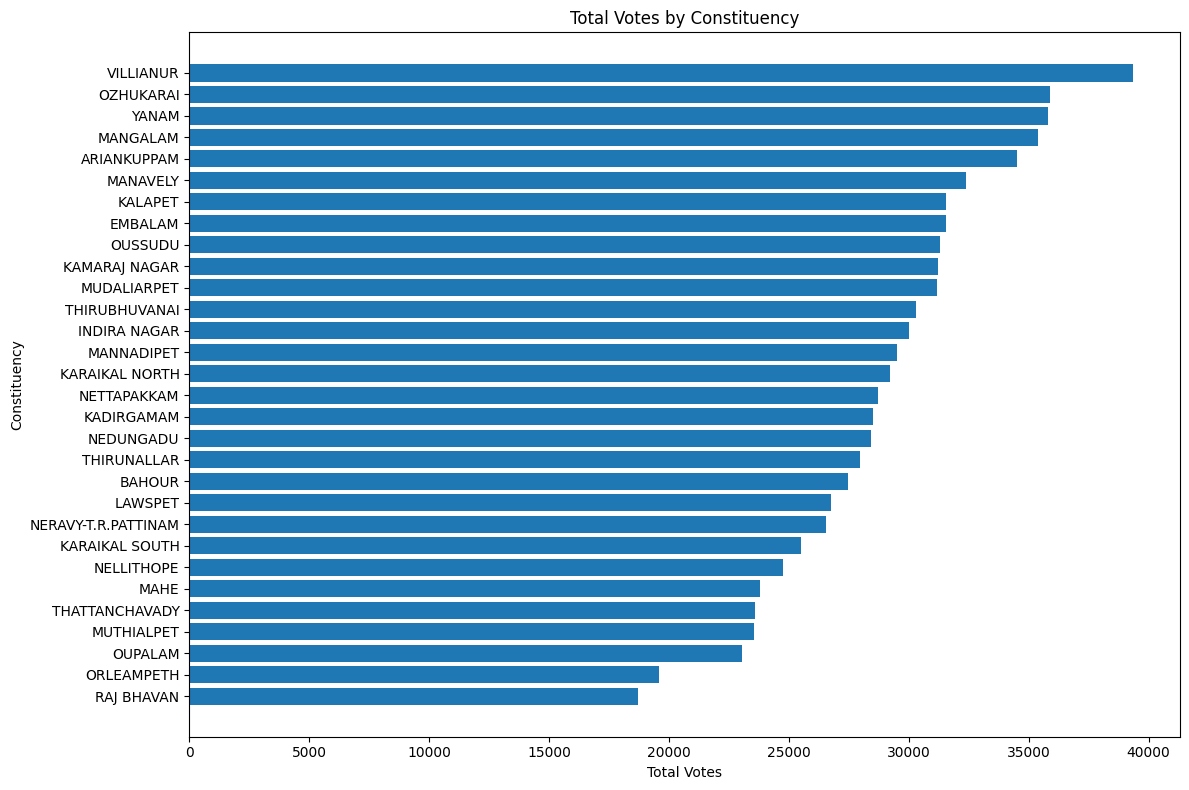

In [55]:
constituency_votes_chart = constituency_votes.sort_values(ascending=True)

plt.figure(figsize=(12, 8))

plt.barh(constituency_votes_chart.index,constituency_votes_chart.values)

plt.title("Total Votes by Constituency")
plt.xlabel("Total Votes")
plt.ylabel("Constituency")

plt.tight_layout()
plt.show()

### Key Insight

The constituency-wise visualization highlights differences in overall voting volume across the 30 constituencies.

**VILLIANUR** recorded the highest total vote count at **39,346**, while **RAJ BHAVAN** recorded the lowest at **18,716**.

The difference between these two constituencies is **20,630 votes**, indicating a substantial variation in total voting volume across the constituencies represented in the dataset.

## Party-wise Vote Share

This analysis calculates the percentage of total votes received by each party category across the dataset.

Vote share provides a standardized measure for comparing the relative contribution of each party to the overall vote total.

### Analysis Question

What percentage of the overall votes was received by each party category?

In [56]:
party_vote_share = (df.groupby("Party")["Total Votes"].sum().sort_values(ascending=False))

party_vote_share_percentage = (party_vote_share / df["Total Votes"].sum() * 100)

party_vote_share_percentage

,Total Votes
Party,
All India N.R. Congress,23.124695
Indian National Congress,17.541526
Tamilaga Vettri Kazhagam,16.719834
Dravida Munnetra Kazhagam,13.743291
Bharatiya Janata Party,12.190076
Independent,8.680477
Latchiya Jananayaka Katchi (LJK),2.297899
Neyam Makkal Kazhagam,1.794516
Naam Tamilar Katchi,1.363869


In [57]:
print("Total Vote Share:",round(party_vote_share_percentage.sum(), 2),"%")

Total Vote Share: 100.0 %


### Interpretation

The party-wise vote-share analysis shows that **All India N.R. Congress** received the largest share of the overall votes, accounting for **23.12%** of the total votes.

**Indian National Congress** recorded the second-highest vote share at **17.54%**, followed by **Tamilaga Vettri Kazhagam** with **16.72%** and **Dravida Munnetra Kazhagam** with **13.74%**. The **Bharatiya Janata Party** accounted for **12.19%**, while **Independent** candidates collectively received **8.68%** of the total votes.

The remaining party categories each accounted for less than 3% of the overall vote share. Among these, **Latchiya Jananayaka Katchi (LJK)** had the highest share at **2.30%**, followed by **Neyam Makkal Kazhagam** at **1.79%** and **Naam Tamilar Katchi** at **1.36%**.

Overall, the vote share is concentrated among the major party categories, with All India N.R. Congress having the largest individual share of the total votes.

##Party-wise Vote Share Visualization

The following visualization compares the percentage of total votes received by each party category.

The parties are displayed in descending order of vote share to make the differences in overall electoral support easier to compare.

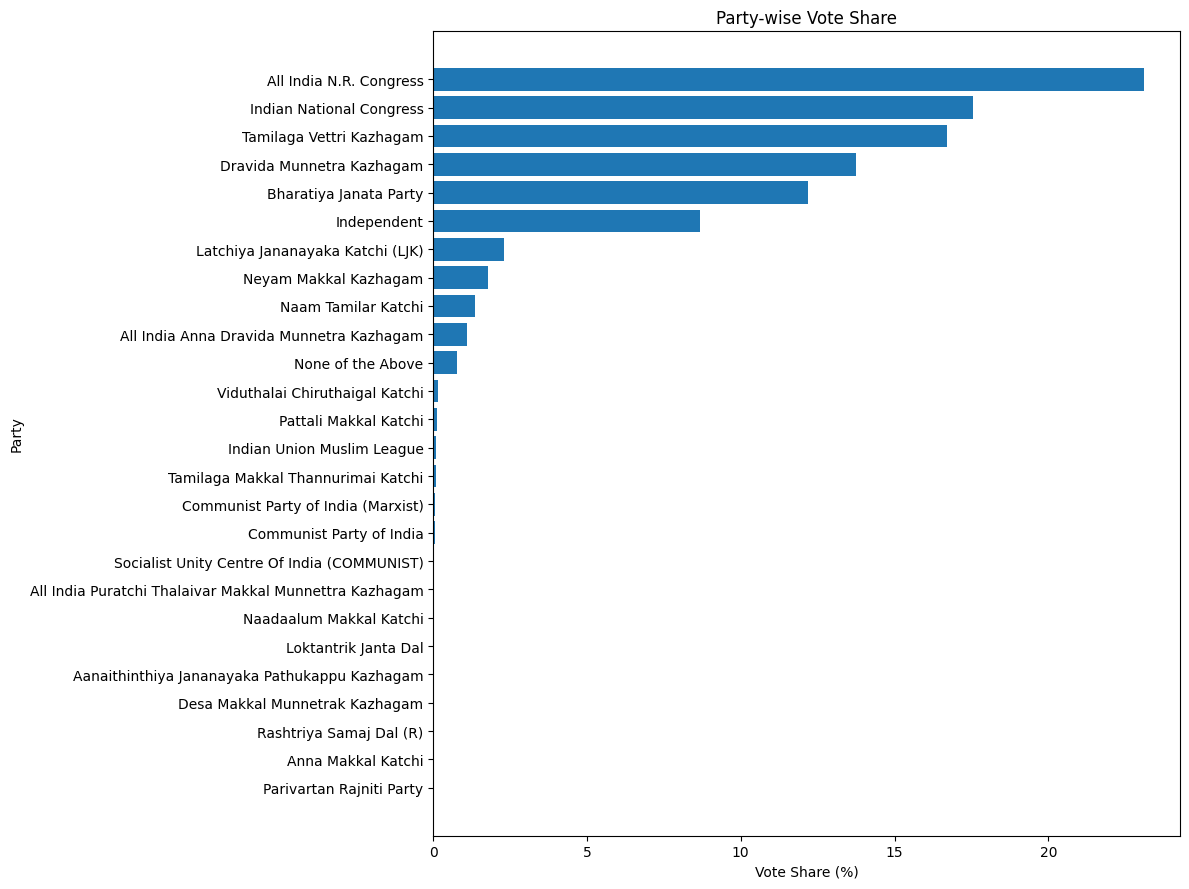

In [58]:
party_vote_share_chart = party_vote_share_percentage.sort_values(ascending=True)

plt.figure(figsize=(12, 9))

plt.barh(party_vote_share_chart.index,party_vote_share_chart.values)

plt.title("Party-wise Vote Share")
plt.xlabel("Vote Share (%)")
plt.ylabel("Party")

plt.tight_layout()
plt.show()

### Key Insight

The visualization shows that **All India N.R. Congress** has the highest overall vote share at **23.12%**.

The next highest shares belong to **Indian National Congress (17.54%)**, **Tamilaga Vettri Kazhagam (16.72%)**, **Dravida Munnetra Kazhagam (13.74%)**, and **Bharatiya Janata Party (12.19%)**.

The chart also highlights the substantial difference between the major party categories and the smaller parties, whose individual vote shares are generally below 3%.

## Party Vote Share vs Constituency Leadership

This analysis compares each party's overall vote share with the number of constituencies in which the party had the highest-vote candidate.

Vote share measures the proportion of total votes received by a party across the dataset, while constituency leadership measures the number of constituencies in which that party had the highest `Total Votes`.

Comparing these two measures helps identify differences between overall vote support and constituency-level leadership.

### Analysis Question

How does each party's overall vote share compare with its number of constituency-level leaders?

In [70]:
party_comparison = pd.DataFrame({"Vote Share (%)": party_vote_share_percentage,
                                 "Constituency Leaders": party_wins}).fillna(0)

party_comparison = party_comparison.sort_values("Vote Share (%)",ascending=False)

party_comparison

,Vote Share (%),Constituency Leaders
Party,,
All India N.R. Congress,23.124695,12.0
Indian National Congress,17.541526,1.0
Tamilaga Vettri Kazhagam,16.719834,2.0
Dravida Munnetra Kazhagam,13.743291,5.0
Bharatiya Janata Party,12.190076,4.0
Independent,8.680477,3.0
Latchiya Jananayaka Katchi (LJK),2.297899,1.0
Neyam Makkal Kazhagam,1.794516,1.0
Naam Tamilar Katchi,1.363869,0.0


### Interpretation

The comparison between party vote share and constituency-level leadership shows that overall vote share and constituency leadership do not always increase proportionally.

**All India N.R. Congress** has the highest overall vote share at **23.12%** and also has the highest number of constituency-level leaders, with **12 out of 30 constituencies**.

However, the relationship is not consistent for all parties. **Indian National Congress** has the second-highest vote share at **17.54%**, but its candidates led in only **1 constituency**. Similarly, **Tamilaga Vettri Kazhagam** recorded a **16.72%** vote share but had **2 constituency-level leaders**.

**Dravida Munnetra Kazhagam** had a lower overall vote share of **13.74%** but had **5 constituency-level leaders**, while the **Bharatiya Janata Party** had **12.19%** vote share and **4 constituency-level leaders**.

Independent candidates accounted for **8.68%** of the total vote share and had the highest vote totals in **3 constituencies**.

Overall, the comparison demonstrates that a party's overall vote share does not necessarily correspond directly to the number of constituencies in which it has the highest-vote candidate. This highlights the difference between overall electoral support and constituency-level concentration of votes.

## Vote Share vs Constituency Leadership Visualization

The following scatter plot compares each party's overall vote share with the number of constituencies in which it had a constituency-level leader.

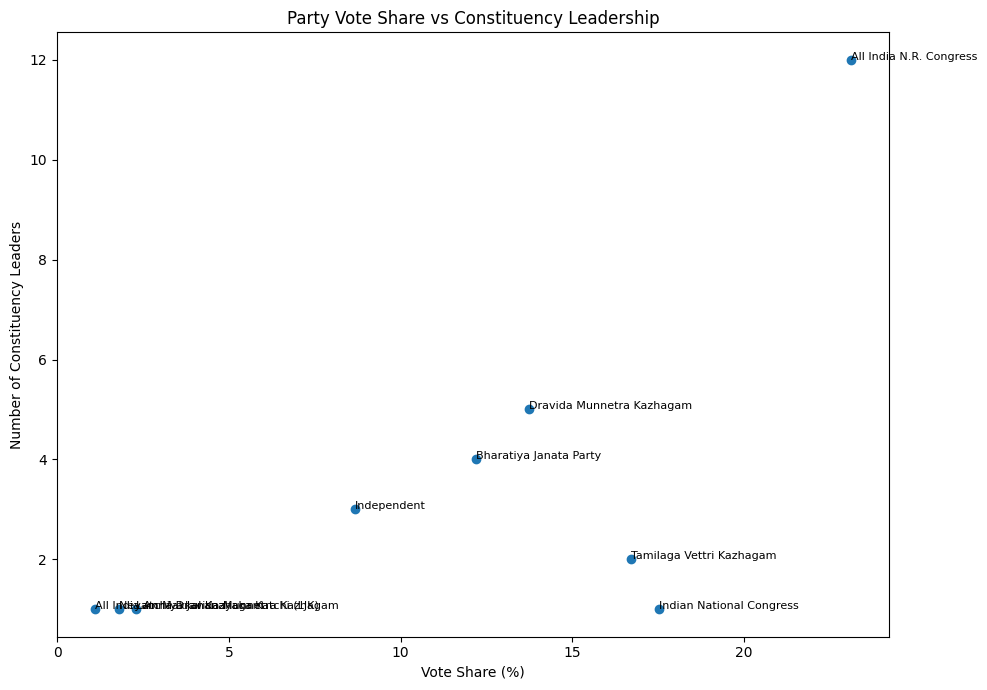

In [71]:
major_party_comparison = party_comparison[party_comparison["Constituency Leaders"] > 0]

plt.figure(figsize=(10, 7))

plt.scatter(major_party_comparison["Vote Share (%)"],major_party_comparison["Constituency Leaders"])

for party, row in major_party_comparison.iterrows():
    plt.annotate(party,(row["Vote Share (%)"], row["Constituency Leaders"]),fontsize=8)

plt.title("Party Vote Share vs Constituency Leadership")
plt.xlabel("Vote Share (%)")
plt.ylabel("Number of Constituency Leaders")

plt.tight_layout()
plt.show()

### Key Insight

The scatter plot demonstrates that party vote share and constituency-level leadership have a positive but uneven relationship.

All India N.R. Congress stands out with both the highest vote share (**23.12%**) and the highest number of constituency-level leaders (**12**).

In contrast, Indian National Congress has a relatively high vote share (**17.54%**) but only **1 constituency-level leader**, while Dravida Munnetra Kazhagam has a lower vote share (**13.74%**) but **5 constituency-level leaders**.

This indicates that the distribution of votes across constituencies can be as important as the overall number of votes when determining constituency-level leadership.

##  Candidate Vote Performance by Party

This analysis identifies the highest-performing candidate within each party based on `Total Votes`.

The purpose is to determine which candidates achieved the highest individual vote totals within their respective parties and to compare their performance across parties.

### Analysis Question

Who is the highest-vote candidate within each party, and how many Total Votes did they receive?

In [72]:
top_candidate_by_party = (df.loc[df.groupby("Party")["Total Votes"].idxmax()]
                         [["Party", "Candidate", "Constituency", "Total Votes", "% of Votes"]]
                         .sort_values("Total Votes", ascending=False))

top_candidate_by_party

,Party,Candidate,Constituency,Total Votes,% of Votes
129,All India N.R. Congress,MALLADI KRISHNA RAO,YANAM,19863,55.44
220,Bharatiya Janata Party,G.N.S. RAJASEKARAN,THIRUNALLAR,16829,60.18
297,Latchiya Jananayaka Katchi (LJK),JOSE CHARLES MARTIN,KAMARAJ NAGAR,16592,53.14
286,Indian National Congress,P. KARTHIKEYAN,OUSSUDU,15400,49.20
10,Dravida Munnetra Kazhagam,R.SIVA,VILLIANUR,15000,38.12
266,Independent,AZHAGU @ AZHAGANANTHAM,KADIRGAMAM,14633,51.35
253,Tamilaga Vettri Kazhagam,B.RAMU,MANAVELY,13822,42.68
316,Neyam Makkal Kazhagam,G. NEHRU ALIAS COUPPOUSSAMY,ORLEAMPETH,9960,50.83
303,All India Anna Dravida Munnetra Kazhagam,A ANBALAGAN,OUPALAM,9099,39.51
28,Viduthalai Chiruthaigal Katchi,PUSHPALATHA,OZHUKARAI,1142,3.18


### Interpretation

The candidate-level analysis identifies the highest-vote candidate within each party based on Total Votes.

Among all party-level top candidates, **MALLADI KRISHNA RAO** of **All India N.R. Congress**, contesting from **YANAM**, recorded the highest Total Votes with **19,863 votes** and **55.44%** of the votes.

He was followed by **G.N.S. RAJASEKARAN** of **Bharatiya Janata Party** from **THIRUNALLAR**, who received **16,829 votes** and **60.18%** of the votes, and **JOSE CHARLES MARTIN** of **Latchiya Jananayaka Katchi (LJK)** from **KAMARAJ NAGAR**, who received **16,592 votes** and **53.14%**.

Among the major parties, the highest-performing candidates were also identified for Indian National Congress, Dravida Munnetra Kazhagam, Independent, and Tamilaga Vettri Kazhagam, with their top candidates receiving 15,400, 15,000, 14,633, and 13,822 votes respectively.

The results also show substantial variation among parties. While some parties had top candidates receiving more than 10,000 votes, several smaller parties had their highest-performing candidates receiving fewer than 500 votes.

Overall, the analysis highlights the strongest individual candidate performance within each party and demonstrates the wide variation in candidate-level electoral support across the dataset.

##Top Candidate Performance Visualization

This visualization compares the highest-performing candidate from each party based on Total Votes.

The candidates are arranged from lowest to highest Total Votes to make differences in individual candidate performance easier to identify.

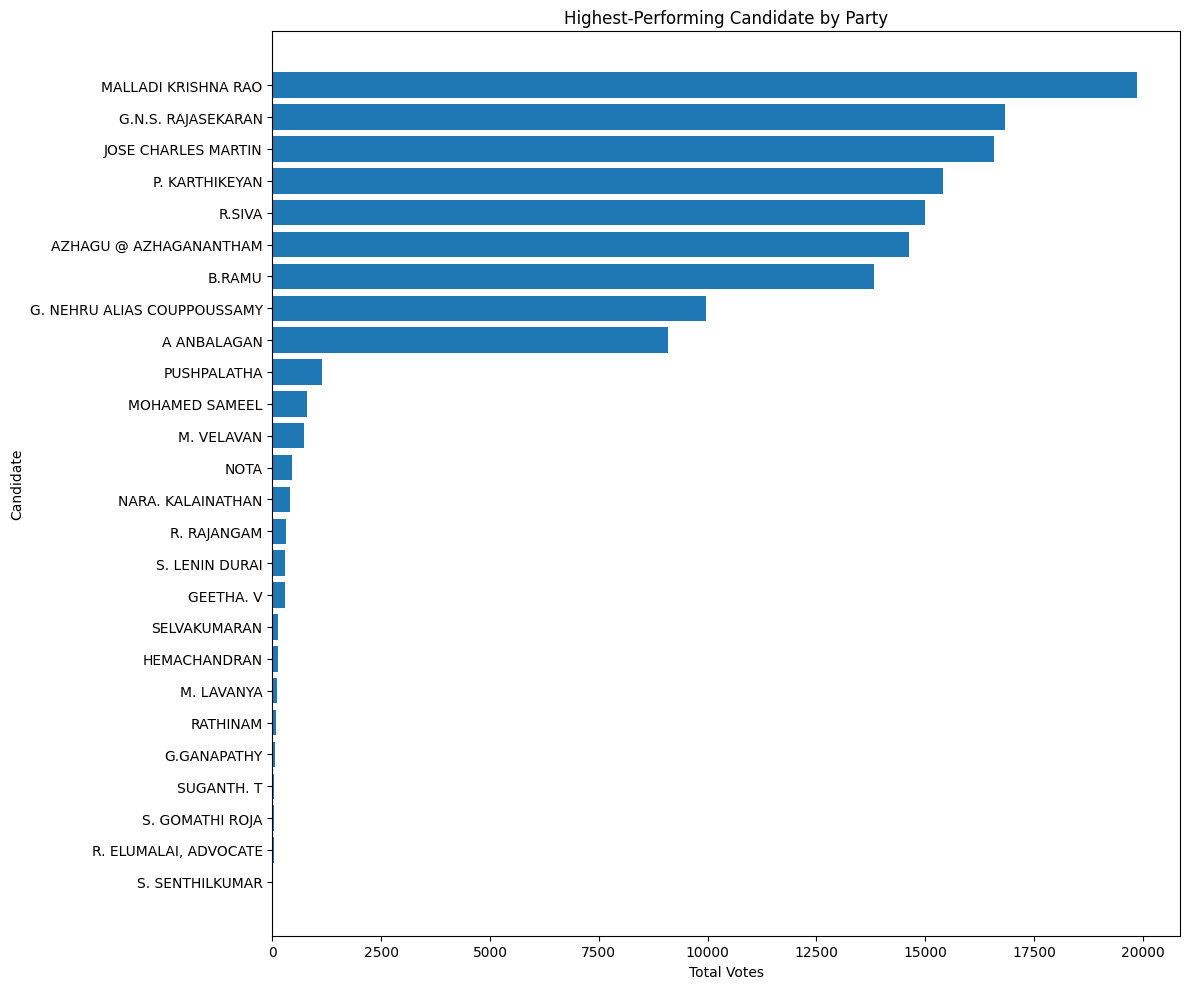

In [73]:
top_candidates_chart = top_candidate_by_party.sort_values("Total Votes",ascending=True)

plt.figure(figsize=(12, 10))

plt.barh(top_candidates_chart["Candidate"],top_candidates_chart["Total Votes"])

plt.title("Highest-Performing Candidate by Party")
plt.xlabel("Total Votes")
plt.ylabel("Candidate")

plt.tight_layout()
plt.show()

### Key Insight

The visualization demonstrates a large difference in the highest-performing candidate's Total Votes across parties.

**MALLADI KRISHNA RAO** recorded the highest Total Votes among the top candidates of all parties, with **19,863 votes**, while several smaller parties had top candidates with fewer than 500 votes.

This indicates that individual candidate performance varies considerably across party categories, with the strongest candidates receiving substantially more votes than candidates representing smaller parties.

##  Candidate Vote Percentage vs Total Votes

This analysis examines the relationship between a candidate's `Total Votes` and their `% of Votes`.

Comparing these two measures helps determine whether candidates receiving a larger number of votes also tend to have a higher percentage of votes within their respective constituencies.

### Analysis Question

Is there a relationship between a candidate's Total Votes and their percentage of votes?

In [75]:
vote_correlation = df["Total Votes"].corr(df["% of Votes"])

print("Correlation between Total Votes and % of Votes:",round(vote_correlation, 3))

Correlation between Total Votes and % of Votes: 0.982


### Interpretation

The correlation analysis shows a correlation coefficient of **0.982** between `Total Votes` and `% of Votes`, indicating a **very strong positive relationship** between the two variables.

This means that candidates with higher Total Votes generally also have higher percentages of votes within their constituencies.

The strong positive relationship is expected because both measures reflect candidate electoral support. However, `% of Votes` also depends on the total number of votes cast in each constituency, so candidates with similar vote totals may have different vote percentages across constituencies.

Overall, the result confirms that Total Votes and Vote Percentage are strongly associated in this dataset.

## Candidate Vote Percentage vs Total Votes Visualization

The following scatter plot visualizes the relationship between `Total Votes` and `% of Votes`.

The visualization helps identify the strength and direction of the relationship observed in the correlation analysis.

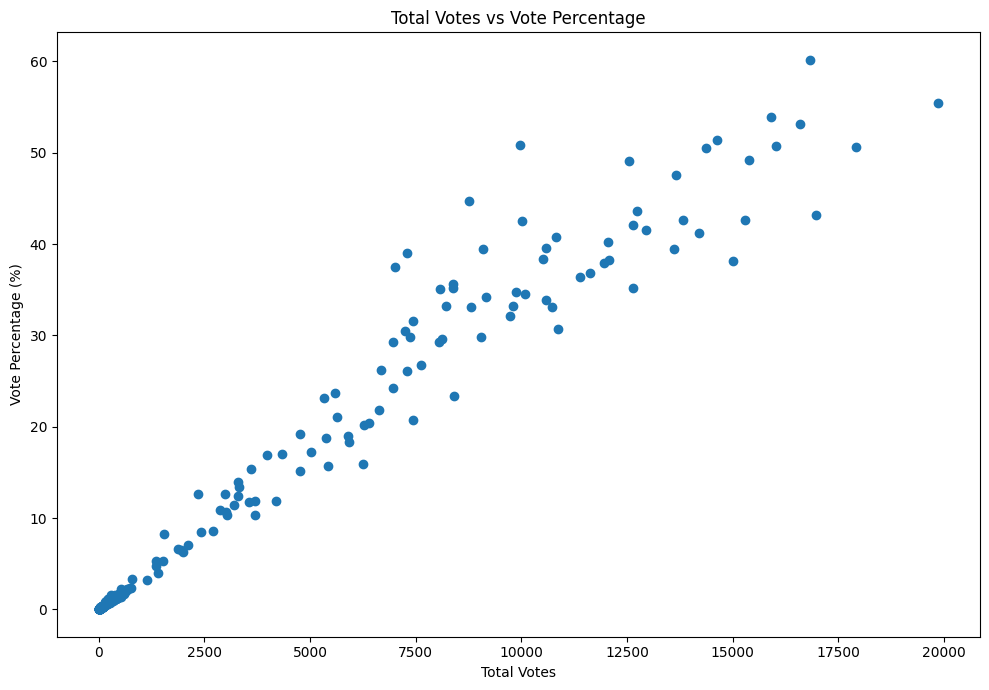

In [76]:
plt.figure(figsize=(10, 7))

plt.scatter(df["Total Votes"],df["% of Votes"])

plt.title("Total Votes vs Vote Percentage")
plt.xlabel("Total Votes")
plt.ylabel("Vote Percentage (%)")

plt.tight_layout()
plt.show()

### Key Insight

The scatter plot shows a strong upward relationship between `Total Votes` and `% of Votes`, consistent with the correlation coefficient of **0.982**.

Candidates with larger Total Vote counts generally appear at higher Vote Percentage values. This confirms that both measures are closely related in the dataset, while differences in constituency-level total votes can cause some variation in the percentage received.

## Constituency Competition Analysis

This analysis evaluates the level of electoral competition across constituencies using the winning margin.

The winning margin is calculated as the difference between the votes received by the winner and the runner-up in each constituency.

A smaller winning margin indicates a more closely contested election, while a larger winning margin indicates a more decisive victory.

### Analysis Question

Which constituencies had the closest and most decisive contests based on the winning margin?

In [77]:
closest_contests = (winning_margin_df.sort_values("Winning Margin", ascending=True))

closest_contests[
    [
        "Constituency",
        "Winner",
        "Winner Party",
        "Winner Votes",
        "Runner-up",
        "Runner-up Party",
        "Runner-up Votes",
        "Winning Margin"
    ]].head(10)

,Constituency,Winner,Winner Party,Winner Votes,Runner-up,Runner-up Party,Runner-up Votes,Winning Margin
24,RAJ BHAVAN,VIGNESH KANNAN,Dravida Munnetra Kazhagam,7304,V. P. RAMALINGAME,Bharatiya Janata Party,7017,287
5,KALAPET,SENTHIL @ RAMESH,Dravida Munnetra Kazhagam,12069,P.M.L. KALYANASUNDARAM,Bharatiya Janata Party,11622,447
3,INDIRA NAGAR,P.V. AROUMOUGAME @ AKD,All India N.R. Congress,12640,S. MOUROUGANE,Tamilaga Vettri Kazhagam,12056,584
0,ARIANKUPPAM,C. AIYAPPAN @ MOUTTAYAPPAN,All India N.R. Congress,14210,VIZAYALAKSHMY DJEAMOURTHY,Indian National Congress,13607,603
26,THIRUBHUVANAI,AK. SAI J SARAVANAN KUMAR,Tamilaga Vettri Kazhagam,9740,B. KOBIGA,All India N.R. Congress,9039,701
17,NELLITHOPE,V. CARTIGUEYANE,Dravida Munnetra Kazhagam,8226,OMSAKTHISEKAR,Independent,7376,850
15,MUTHIALPET,VAIYAPURI MANIKANDAN,All India N.R. Congress,8382,EERAM G. RAJENDRAN,Indian National Congress,7430,952
21,OUPALAM,A ANBALAGAN,All India Anna Dravida Munnetra Kazhagam,9099,S SIVA,Tamilaga Vettri Kazhagam,8073,1026
10,MAHE,ADV. T. ASHOK KUMAR,Independent,8375,RAMESH PARAMBATH,Indian National Congress,7260,1115
20,ORLEAMPETH,G. NEHRU ALIAS COUPPOUSSAMY,Neyam Makkal Kazhagam,9960,S. GOPAL,Dravida Munnetra Kazhagam,8759,1201


In [78]:
largest_margins = (winning_margin_df.sort_values("Winning Margin", ascending=False))

largest_margins[
    [
        "Constituency",
        "Winner",
        "Winner Party",
        "Winner Votes",
        "Runner-up",
        "Runner-up Party",
        "Runner-up Votes",
        "Winning Margin"
    ]].head(10)

,Constituency,Winner,Winner Party,Winner Votes,Runner-up,Runner-up Party,Runner-up Votes,Winning Margin
6,KAMARAJ NAGAR,JOSE CHARLES MARTIN,Latchiya Jananayaka Katchi (LJK),16592,P.K. DEVADOSS,Indian National Congress,6387,10205
27,THIRUNALLAR,G.N.S. RAJASEKARAN,Bharatiya Janata Party,16829,R. KAMALAKANNAN,Indian National Congress,7303,9526
12,MANGALAM,N. RANGASAMY,All India N.R. Congress,17917,S.S. RANGAN,Dravida Munnetra Kazhagam,10867,7050
4,KADIRGAMAM,AZHAGU @ AZHAGANANTHAM,Independent,14633,K.S.P @ S. RAMESH,All India N.R. Congress,7629,7004
19,NETTAPAKKAM,P. RAJAVELU,All India N.R. Congress,13665,G. ANBARASAN,Indian National Congress,6976,6689
13,MANNADIPET,A. NAMASSIVAYAM,Bharatiya Janata Party,15918,T.P.R. SELVAME,Indian National Congress,9808,6110
8,KARAIKAL SOUTH,A.M.H. NAZEEM,Dravida Munnetra Kazhagam,12543,AVS SAKTHIVEL PRABU,Indian National Congress,6681,5862
29,YANAM,MALLADI KRISHNA RAO,All India N.R. Congress,19863,GOLLAPALLI SRINIVAS ASHOK,Indian National Congress,15295,4568
16,NEDUNGADU,DR. V. VIGNESWARAN,Independent,14368,C. CHANDIRA PRIYANGA,All India N.R. Congress,9869,4499
25,THATTANCHAVADY,N. RANGASAMY,All India N.R. Congress,10024,E. VINAYAGAM,Neyam Makkal Kazhagam,5583,4441


In [80]:
print("Average Winning Margin:",round(winning_margin_df["Winning Margin"].mean(), 2))

print("Smallest Winning Margin:",winning_margin_df["Winning Margin"].min())

print("Largest Winning Margin:",winning_margin_df["Winning Margin"].max())

Average Winning Margin: 3398.4
Smallest Winning Margin: 287
Largest Winning Margin: 10205


### Interpretation

The constituency competition analysis shows considerable variation in the winning margins across the 30 constituencies.

The **average winning margin was 3,398.4 votes**, indicating that, on average, constituency winners secured a substantial lead over their respective runners-up.

The **closest contest was in RAJ BHAVAN**, where VIGNESH KANNAN of the Dravida Munnetra Kazhagam defeated V. P. RAMALINGAME of the Bharatiya Janata Party by only **287 votes**. Other closely contested constituencies included KALAPET with a margin of **447 votes**, INDIRA NAGAR with **584 votes**, and ARIANKUPPAM with **603 votes**.

In contrast, the **largest winning margin was recorded in KAMARAJ NAGAR**, where JOSE CHARLES MARTIN of Latchiya Jananayaka Katchi (LJK) won by **10,205 votes**. This was followed by THIRUNALLAR with a margin of **9,526 votes** and MANGALAM with a margin of **7,050 votes**.

Overall, the results indicate that electoral competition varied significantly across constituencies. Some constituencies were highly competitive, with winners securing only a few hundred votes more than their runners-up, while others resulted in decisive victories with margins exceeding 7,000 votes.

## Winning Margin by Constituency

The following visualization compares the winning margins across all constituencies. A smaller margin represents a more closely contested constituency, while a larger margin represents a more decisive victory.

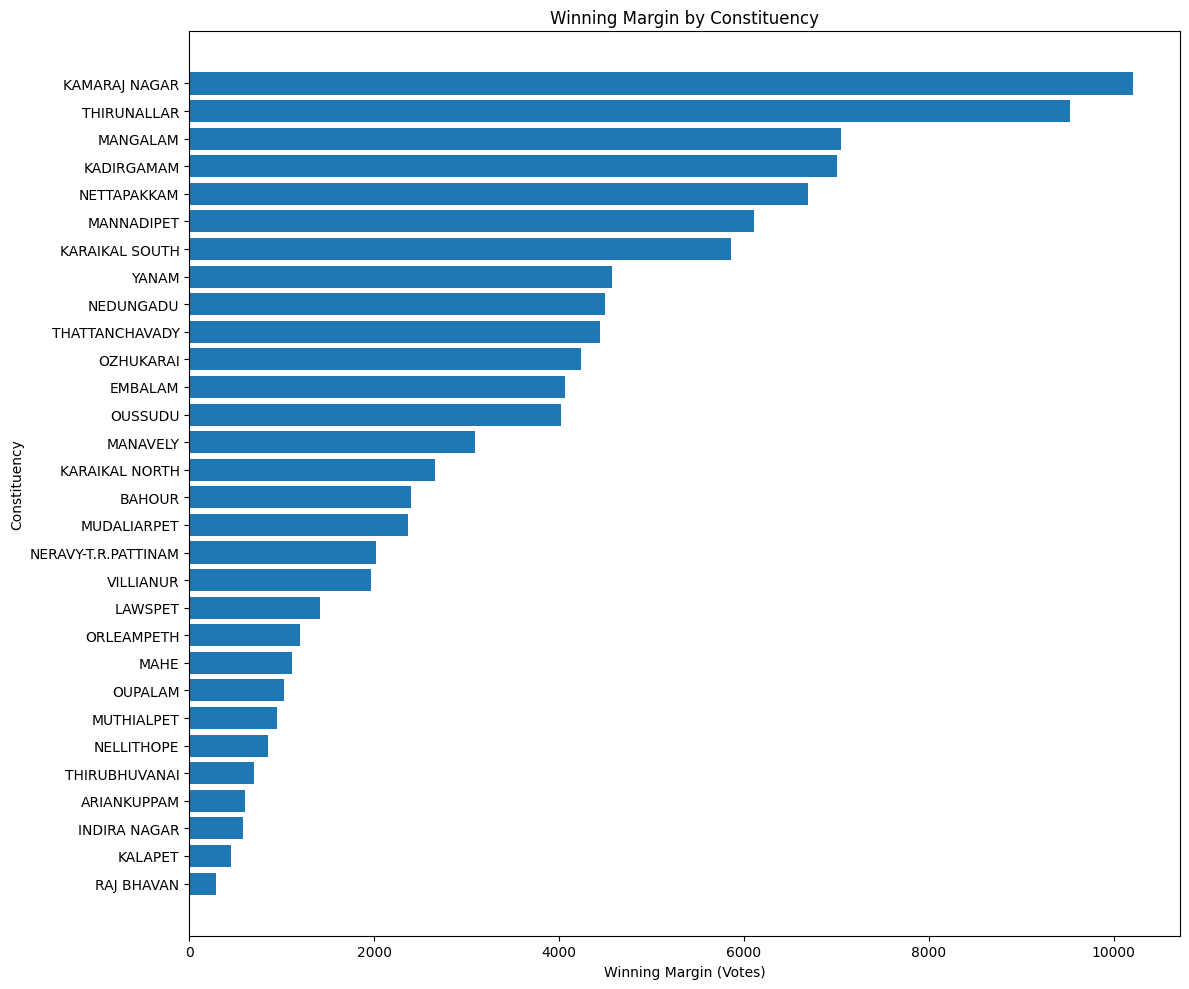

In [81]:
margin_chart = winning_margin_df.sort_values("Winning Margin",ascending=True)

plt.figure(figsize=(12, 10))

plt.barh(margin_chart["Constituency"],margin_chart["Winning Margin"])

plt.title("Winning Margin by Constituency")
plt.xlabel("Winning Margin (Votes)")
plt.ylabel("Constituency")

plt.tight_layout()
plt.show()

### Key Insight

The winning-margin visualization clearly demonstrates the variation in electoral competitiveness across constituencies.

RAJ BHAVAN, KALAPET, INDIRA NAGAR, and ARIANKUPPAM were among the most closely contested constituencies, with winning margins below 1,000 votes.

On the other hand, KAMARAJ NAGAR, THIRUNALLAR, MANGALAM, and KADIRGAMAM recorded much larger winning margins, indicating more decisive victories.

Therefore, winning margins provide an important measure of constituency-level electoral competition that cannot be understood from total vote counts alone.

## Party-wise Total Votes

This visualization presents the total votes received by each party. It highlights the parties that obtained the largest share of votes across all constituencies and provides an overall comparison of party-level electoral performance.

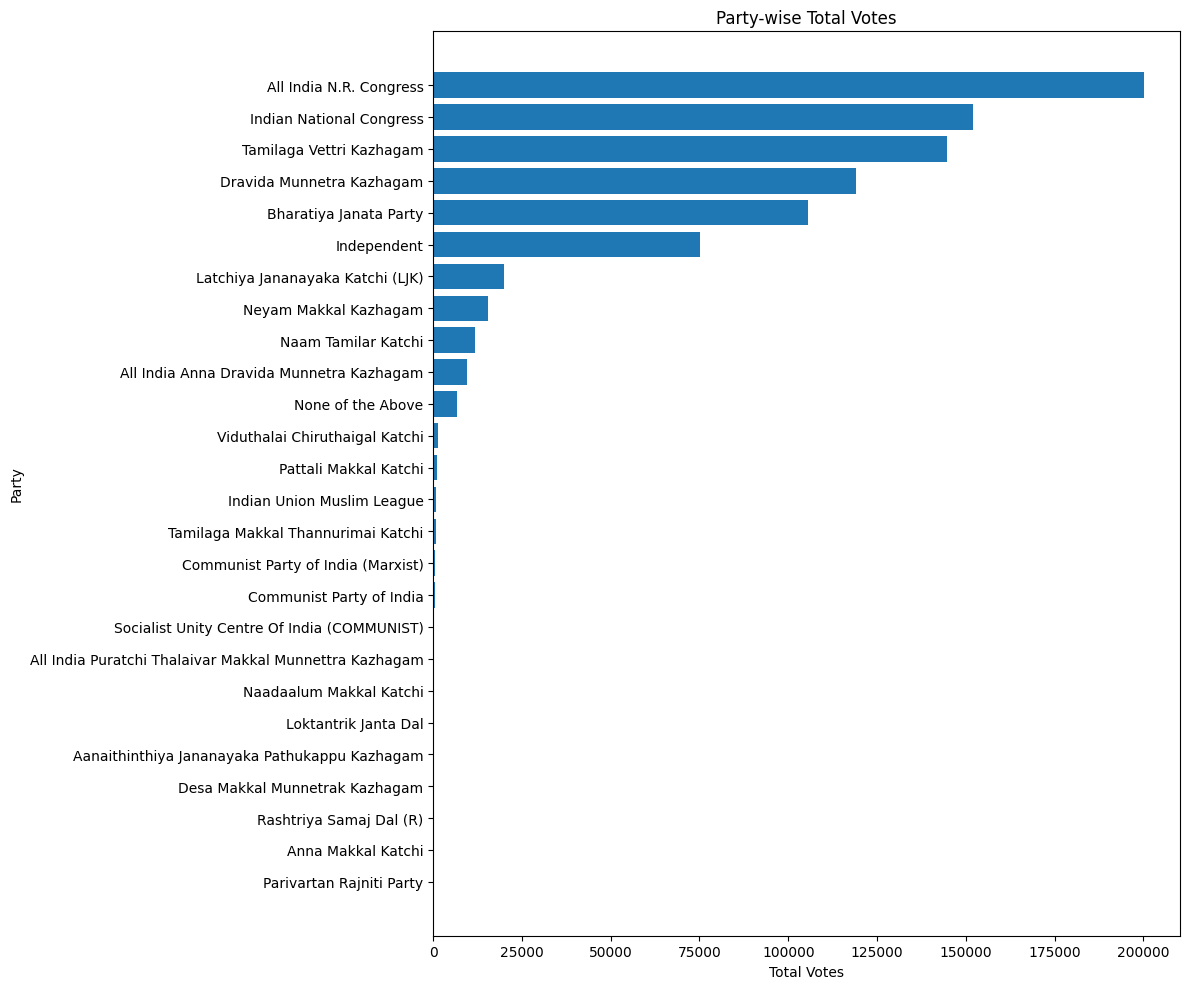

In [4]:
party_votes = (df.groupby("Party")["Total Votes"].sum().sort_values(ascending=False))

plt.figure(figsize=(12, 10))

plt.barh(party_votes.index[::-1],party_votes.values[::-1])

plt.title("Party-wise Total Votes")
plt.xlabel("Total Votes")
plt.ylabel("Party")

plt.tight_layout()
plt.show()

### Key Finding

All India N.R. Congress recorded the highest total number of votes with **200,292 votes**, followed by Indian National Congress with **151,934 votes** and Tamilaga Vettri Kazhagam with **144,817 votes**.

This demonstrates the strong overall electoral support received by these parties across the constituencies.

## Party-wise Vote Share

This visualization shows the percentage of total votes obtained by each party. Vote share provides a standardized measure for comparing party performance across the entire dataset.

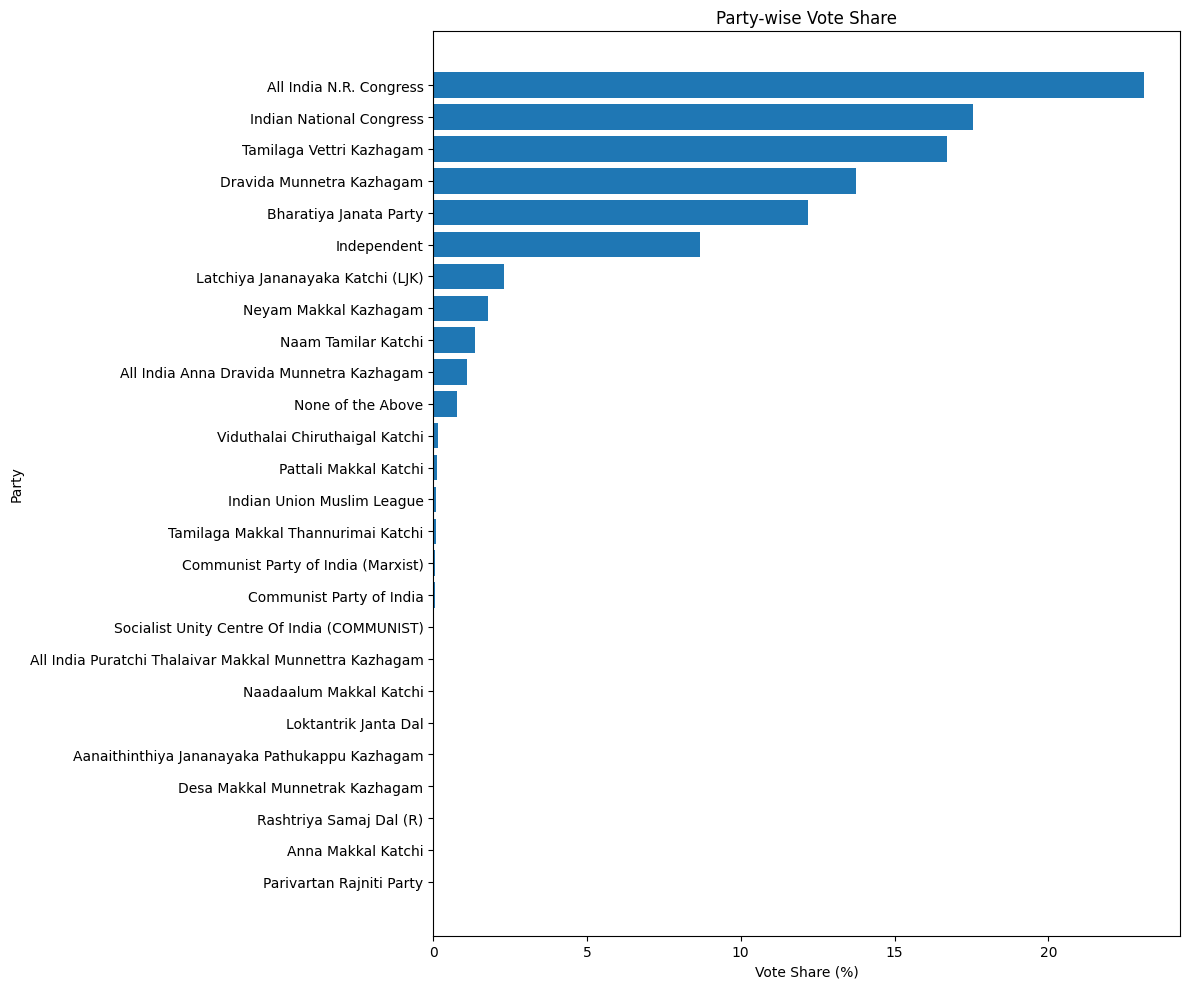

In [5]:
party_vote_share = (df.groupby("Party")["Total Votes"].sum())

party_vote_share = (party_vote_share / party_vote_share.sum() * 100).sort_values(ascending=False)

plt.figure(figsize=(12, 10))

plt.barh(party_vote_share.index[::-1],party_vote_share.values[::-1])

plt.title("Party-wise Vote Share")
plt.xlabel("Vote Share (%)")
plt.ylabel("Party")

plt.tight_layout()
plt.show()

### Key Finding

All India N.R. Congress had the highest vote share at **23.12%**, followed by Indian National Congress at **17.54%**, Tamilaga Vettri Kazhagam at **16.72%**, Dravida Munnetra Kazhagam at **13.74%**, and Bharatiya Janata Party at **12.19%**.

These five parties together accounted for the majority of the votes in the dataset, showing that electoral support was concentrated among a relatively small number of major parties.

## Party-wise Constituency Wins

This visualization compares the number of constituencies won by each party.

Unlike total votes or vote share, constituency wins indicate how effectively a party converted electoral support into victories across individual constituencies.

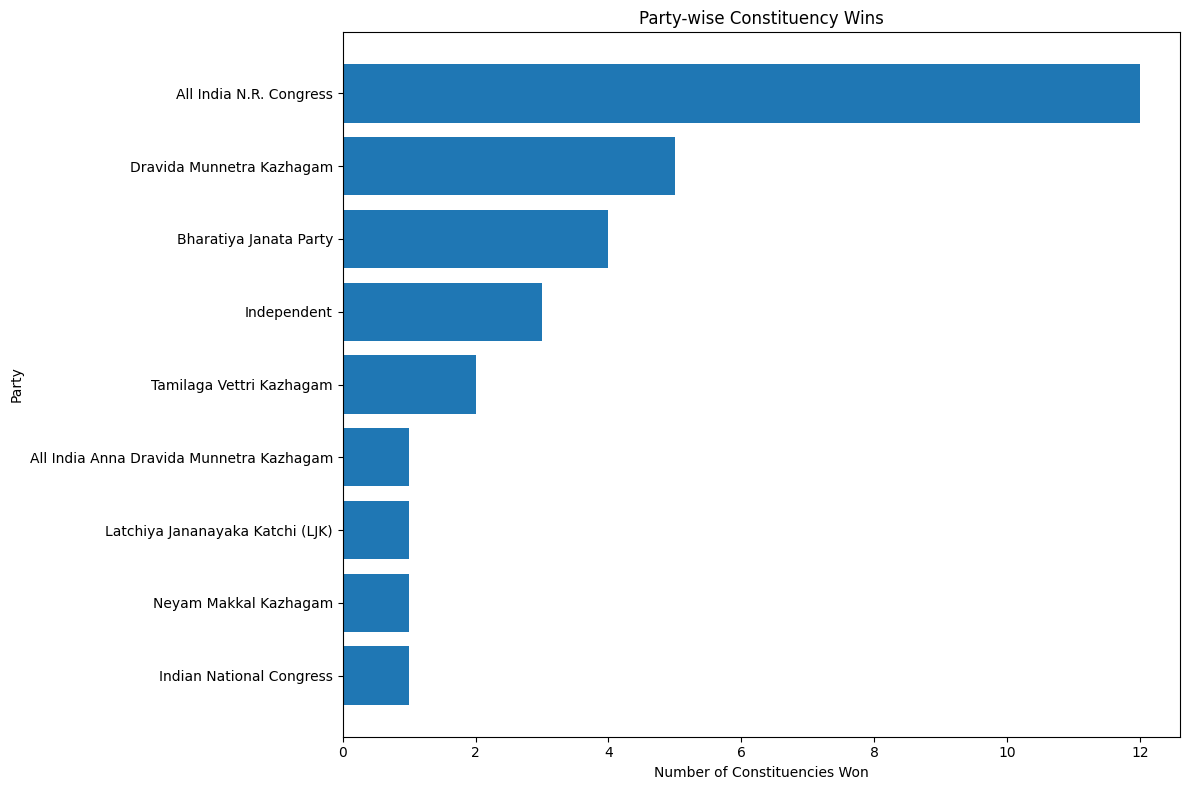

In [8]:
party_wins = (winning_margin_df["Winner Party"].value_counts().sort_values(ascending=True))

plt.figure(figsize=(12, 8))

plt.barh(party_wins.index,party_wins.values)

plt.title("Party-wise Constituency Wins")
plt.xlabel("Number of Constituencies Won")
plt.ylabel("Party")

plt.tight_layout()
plt.show()

### Key Finding

All India N.R. Congress won the highest number of constituencies with **12 wins**, followed by Dravida Munnetra Kazhagam with **5 wins** and Bharatiya Janata Party with **4 wins**.

Independent candidates won **3 constituencies**, while Tamilaga Vettri Kazhagam won **2 constituencies**.

This demonstrates that a party's total vote share and its number of constituency victories are related but are not necessarily proportional.

## Winning Margin by Constituency

This visualization highlights the competitiveness of the elections across constituencies.

Smaller winning margins represent closely contested constituencies, while larger margins represent more decisive victories.

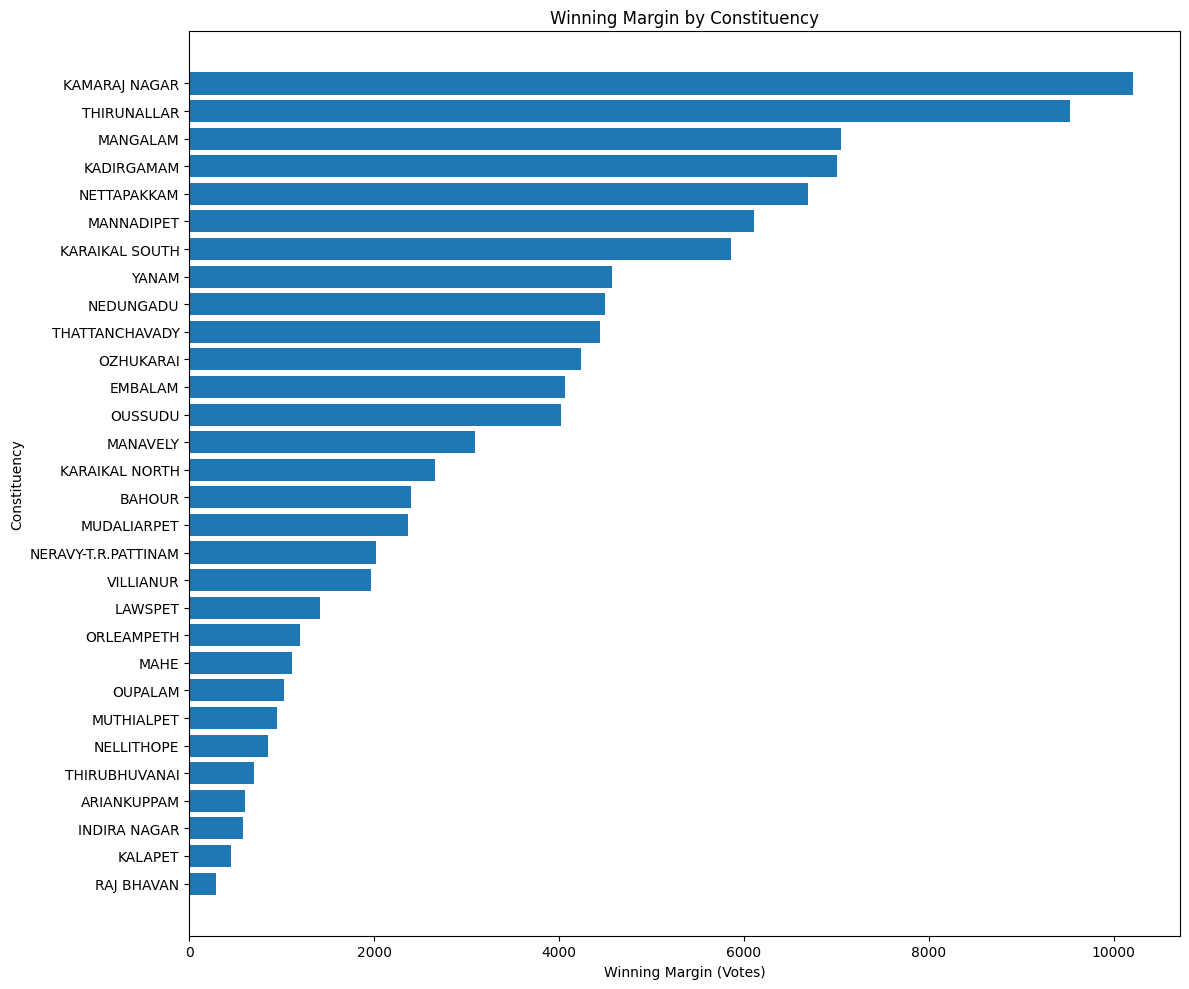

In [9]:
margin_chart = winning_margin_df.sort_values("Winning Margin",ascending=True)

plt.figure(figsize=(12, 10))

plt.barh(margin_chart["Constituency"],margin_chart["Winning Margin"])

plt.title("Winning Margin by Constituency")
plt.xlabel("Winning Margin (Votes)")
plt.ylabel("Constituency")

plt.tight_layout()
plt.show()

### Key Finding

The closest contest occurred in **RAJ BHAVAN**, where the winning margin was only **287 votes**.

The largest winning margin occurred in **KAMARAJ NAGAR**, where the winner secured a margin of **10,205 votes**.

The average winning margin across the constituencies was **3,398.4 votes**, indicating substantial variation in the level of electoral competition.

## EVM Votes vs Postal Votes

This visualization compares the total votes received through Electronic Voting Machines (EVM) and Postal Ballots.

The comparison provides an overview of the contribution of each voting method to the overall election results.

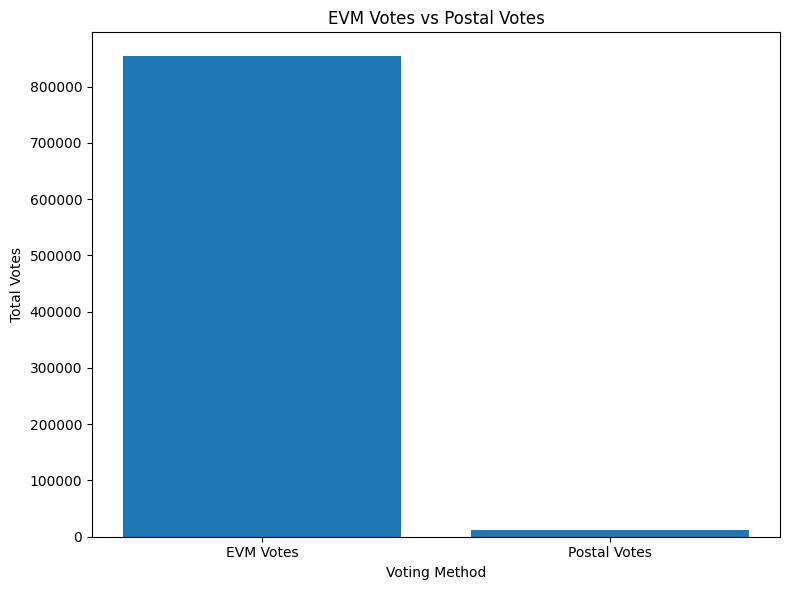

In [10]:
evm_total = df["EVM Votes"].sum()
postal_total = df["Postal Votes"].sum()

vote_methods = pd.Series({"EVM Votes": evm_total,"Postal Votes": postal_total})

plt.figure(figsize=(8, 6))

plt.bar(vote_methods.index,vote_methods.values)

plt.title("EVM Votes vs Postal Votes")
plt.xlabel("Voting Method")
plt.ylabel("Total Votes")

plt.tight_layout()
plt.show()

### Key Finding

The dataset contains **853,899 EVM votes** and **12,240 Postal votes**, giving a total of **866,139 votes**.

EVM votes therefore represent the overwhelming majority of votes recorded in the dataset, while postal votes account for a much smaller proportion.

## Total Votes vs Vote Percentage

This scatter plot examines the relationship between a candidate's Total Votes and their Vote Percentage.

The visualization complements the correlation analysis and helps identify the strength and direction of the relationship between the two variables.

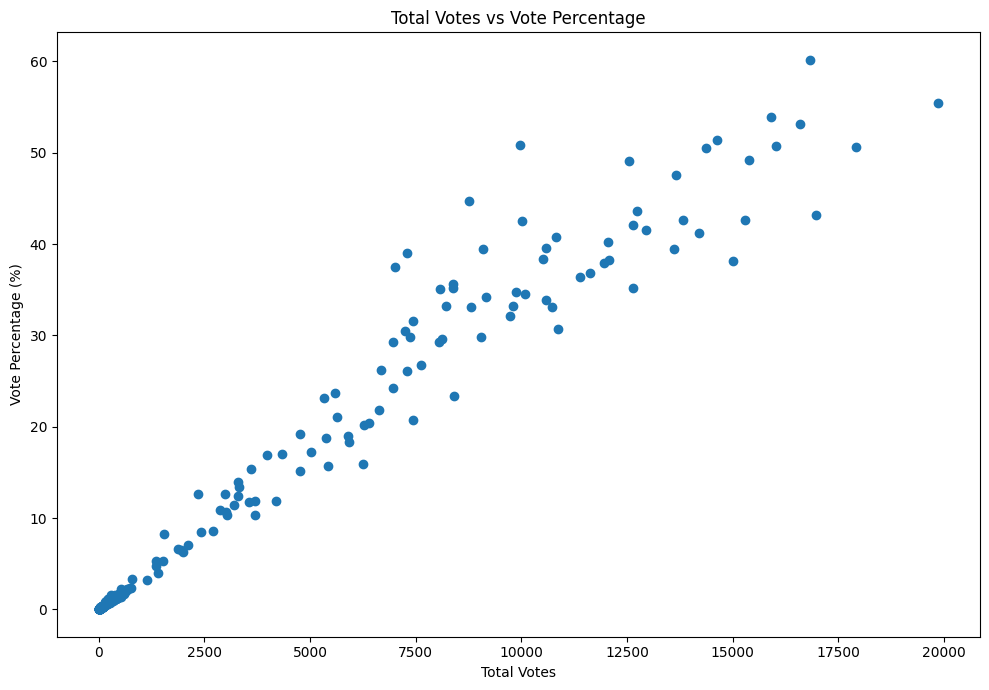

In [11]:
plt.figure(figsize=(10, 7))

plt.scatter(df["Total Votes"],df["% of Votes"])

plt.title("Total Votes vs Vote Percentage")
plt.xlabel("Total Votes")
plt.ylabel("Vote Percentage (%)")

plt.tight_layout()
plt.show()

### Key Finding

The analysis identified a correlation of **0.982** between Total Votes and Vote Percentage, indicating a very strong positive relationship.

Candidates with higher Total Vote counts generally also achieved higher Vote Percentage values. The scatter plot visually confirms this strong positive association.

##Overall Key Findings

The analysis of the election dataset produced several important findings:

1. **Party Performance:**  
   All India N.R. Congress recorded the highest total votes with **200,292 votes** and also achieved the highest number of constituency victories with **12 wins**.

2. **Vote Share:**  
   All India N.R. Congress had the highest overall vote share at **23.12%**, followed by Indian National Congress at **17.54%** and Tamilaga Vettri Kazhagam at **16.72%**.

3. **Candidate Performance:**  
   MALLADI KRISHNA RAO of All India N.R. Congress recorded the highest Total Votes among the top-performing candidates of each party, receiving **19,863 votes** in YANAM.

4. **Highest Vote Percentage:**  
   G.N.S. RAJASEKARAN of Bharatiya Janata Party recorded the highest vote percentage among the candidates examined, with **60.18%** in THIRUNALLAR.

5. **Electoral Competition:**  
   RAJ BHAVAN was the closest contest, with a winning margin of only **287 votes**, while KAMARAJ NAGAR recorded the largest winning margin of **10,205 votes**.

6. **Voting Method:**  
   The dataset contains **853,899 EVM votes** compared with **12,240 Postal votes**, showing that EVM voting accounted for the overwhelming majority of recorded votes.

7. **Relationship Between Vote Measures:**  
   Total Votes and Vote Percentage showed a very strong positive correlation of **0.982**, indicating that candidates receiving more votes generally also achieved higher vote percentages.

Overall, the analysis demonstrates significant variation in party performance, candidate support, constituency competitiveness, and voting patterns across the election dataset.

# Conclusion

This project analyzed the election results dataset collected from the official Election Commission website. The analysis covered data quality validation, candidate and party participation, voting patterns, party performance, constituency-level results, winning margins, and candidate-level electoral performance.

The dataset contained **324 candidate records**, representing **26 parties/categories** across **30 constituencies**. The data quality checks confirmed that there were no missing values requiring treatment, and the validation checks showed that the recorded vote totals were consistent with the EVM and Postal Vote components.

The exploratory analysis showed substantial differences in electoral performance across parties and constituencies. **All India N.R. Congress** recorded the highest total votes with **200,292 votes** and won the highest number of constituencies with **12 wins**. Its overall vote share was **23.12%**.

At the constituency level, electoral competition varied considerably. **RAJ BHAVAN** had the closest contest, with a winning margin of only **287 votes**, while **KAMARAJ NAGAR** recorded the largest winning margin of **10,205 votes**.

At the candidate level, **MALLADI KRISHNA RAO** recorded the highest Total Votes with **19,863 votes** in YANAM. **G.N.S. RAJASEKARAN** recorded the highest Vote Percentage among the candidates, with **60.18%** in THIRUNALLAR.

The analysis also showed that EVM voting accounted for the overwhelming majority of recorded votes, with **853,899 EVM votes** compared with **12,240 Postal votes**.

Finally, the correlation analysis produced a value of **0.982** between Total Votes and Vote Percentage, indicating a very strong positive relationship between the two measures.

Overall, this project demonstrates how election-result data can be systematically cleaned, validated, analyzed, and visualized to identify meaningful patterns in party performance, candidate support, and constituency-level electoral competition.

## Key Findings Summary

| Metric | Finding |
|---|---|
| Candidate Records | 324 |
| Unique Parties/Categories | 26 |
| Unique Constituencies | 30 |
| Highest Party Total Votes | All India N.R. Congress — 200,292 |
| Highest Party Vote Share | All India N.R. Congress — 23.12% |
| Most Constituency Wins | All India N.R. Congress — 12 |
| Highest Candidate Total Votes | MALLADI KRISHNA RAO — 19,863 |
| Highest Candidate Vote Percentage | G.N.S. RAJASEKARAN — 60.18% |
| Closest Contest | RAJ BHAVAN — 287 votes |
| Largest Winning Margin | KAMARAJ NAGAR — 10,205 votes |
| Total EVM Votes | 853,899 |
| Total Postal Votes | 12,240 |
| Total Votes | 866,139 |
| Vote Correlation | 0.982 |

##Future Scope

The current analysis can be extended in several ways:

1. Compare electoral performance across multiple election years to identify changes in party support over time.

2. Analyze constituency-level changes in winning margins across different elections.

3. Examine the relationship between candidate characteristics and electoral performance if additional candidate-level information is available.

4. Develop an interactive dashboard allowing users to select a party or constituency and explore its electoral results.

5. Perform geographic analysis to visualize party dominance and constituency-level voting patterns on a map.

6. Apply statistical or machine-learning techniques to study factors associated with electoral outcomes, provided suitable additional data is available.

#Final Project Summary

This project analyzed election results using Python and Pandas, beginning with data cleaning and validation and progressing through exploratory data analysis and visualization.

The analysis examined candidate participation, party performance, vote distribution, constituency-level results, winning margins, voting methods, party vote share, and candidate performance.

The dataset contains **324 candidate records**, **26 parties/categories**, and **30 constituencies**. The analysis identified **All India N.R. Congress** as the party with the highest total votes and the highest number of constituency victories.

The analysis also identified significant differences in electoral competitiveness. Winning margins ranged from **287 votes** in RAJ BHAVAN to **10,205 votes** in KAMARAJ NAGAR.

Overall, the project demonstrates the complete data-analysis workflow: data collection, cleaning, validation, transformation, exploratory analysis, visualization, interpretation, and final reporting.